# Sociolinguistics — does the corpus record enough about its speakers to carry a paper?

The EDA notebook asks what the corpus holds and how recognisers fare on it. This one asks a
different question of the same file, `exports/analytics/analytics.jsonl` (`make export`): **is
there enough social metadata, attached to enough independent speakers, for a sociolinguistic
study of Nepali–English code-mixing?** The answer has two halves. What the corpus *records*
about a speaker is deliberately narrow: a gender and a twenty-year age bracket, typed by the
annotator from having watched the episode or set on the voice after listening to it, and a
host/guest role (D56, D58, D104). Name, dialect and origin were refused on purpose, and no model
infers anything about a speaker from audio.
What the corpus *lets you derive* is wider: who talks to whom, in what register, how the
English gets in, which address forms are used, and how each of these varies by the recorded
variables.

Twelve questions, in this order:

1. **The inventory.** What a sociolinguistic study asks of a corpus, and which of those the export records, lets you derive, or refuses.
2. **Voices, not clips.** How many independent speakers sit in each demographic cell, and for how long.
3. **Giving each voice its words.** Attributing clip text to a speaker.
4. **Code-mixing across speakers**, by gender, age, role and genre: the groups as they are, then one model per measure with genre and show held fixed.
5. **How the English gets in.** Single-word insertion, multi-word alternation, English stems with Nepali morphology, English function words.
6. **The moment of the switch.** Which words carry it, whether a pause comes before it, whether the speech around it changes speed.
7. **Address and honorifics.** The Nepali T/V system (*hajur / tapāī̃ / timī / tã*) by role and genre.
8. **Discourse markers**, Nepali and English, by group.
9. **Accommodation.** Does a host's mixing track the guest's, episode by episode?
10. **Turn-taking by gender pairing.**
11. **What a comparison could detect.** Minimum detectable differences at the current speaker counts.
12. **Verdict**, printed from the frames above.

Every unit of analysis below is a **voice** (an anonymous, cross-episode linked speaker, D87),
never a clip: clips of one person are not independent draws, and a paper's n is its speakers.
The notebook runs no speech model. Everything comes from the reference transcripts, their timed
words and the metadata.

In [1]:
import json
import re
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Same palette as 01_EDA.ipynb: the first three slots of the reference categorical palette, one
# blue ramp for anything ordered, grey for the unknown.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a"]
SPLITS = ["train", "val", "gold"]
GENDERS = ["female", "male"]
GENDER_COLOR = {"female": "#2a78d6", "male": "#eb6834", "unresolved": "#b9b7b0", "mixed": "#1baf7a"}
AGE_ORDER = ["under_20", "20_39", "40_59", "60_79", "80_plus"]
ROLES = ["host", "guest"]
ROLE_COLOR = {"host": "#2a78d6", "guest": "#eb6834"}
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
GREY = "#b9b7b0"
INK, MUTED = "#0b0b0b", "#52514e"

plt.style.use("default")
plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next((n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans") if n in _installed), None)


def script_aware(texts):
    """Give labels that contain Devanagari a font list that can draw both scripts."""
    for text in texts:
        if DEVA_FONT and re.search(r"[ऀ-ॿ]", text.get_text()):
            text.set_fontfamily(["DejaVu Sans", DEVA_FONT])
    return texts


def save(fig, name):
    fig.savefig(FIGURES / f"socio_{name}.png", dpi=150, bbox_inches="tight")


def pretty(v):
    """``20_39`` reads as a range, ``talk_show`` as two words."""
    return re.sub(r"(?<=\d)_(?=\d)", "-", str(v)).replace("_", " ")


pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

manifest = json.loads((ANALYTICS.parent / "manifest.json").read_text())
SCRIBE = "elevenlabs-scribe-v2"  # the recogniser that reports its own word timings, for section 6
REELS = "shorts_reels"           # the bucket the short-form uploads were filed under: not a show
rows, EP_META, talk, WHO, ROLE, LABEL_WORDS, SCRIBE_WORDS = [], {}, {}, {}, {}, {}, {}
with ANALYTICS.open(encoding="utf-8") as fh:
    for line in fh:
        r = json.loads(line)
        meta = r["episode_metadata"] or {}
        cls = r["classes"]
        vad = r["vad_spans"] or []
        per_voice = defaultdict(float)
        for t in r["speaker_turns"] or []:
            if t["voice"]:
                per_voice[t["voice"]] += t["end"] - t["start"]
                # Who the voice is, as the harness resolves it (D107): one gender and age per
                # voice, one role per voice and episode.
                WHO[t["voice"]] = (t["gender"], t["age_bracket"])
                if t["role"]:
                    ROLE[(r["episode_id"], t["voice"])] = t["role"]
        talk[r["segment_id"]] = dict(per_voice)
        rows.append({
            "segment_id": r["segment_id"], "episode": r["episode_id"],
            "split": "gold" if r["pot"] == "gold" else r["split"],
            "tier": r["verification_tier"], "disposition": r["disposition"],
            "duration": r["duration_seconds"], "speech_s": sum(b - a for a, b in vad),
            "genre": meta.get("genre") or "unclassified", "topic": meta.get("topic") or "unclassified",
            # The show as filed at ingest (D108). A reel is its own recording, not an episode of
            # a show called shorts_reels, so it groups by its own id.
            "show": r["show_id"] if r["show_id"] and r["show_id"] != REELS else r["episode_id"],
            "declared": len(meta.get("speakers") or {}),
            "overlap_s": sum(b - a for a, b in r["overlap_spans"]),
            "turn_changes": max(0, len(r["speaker_turns"] or []) - 1),
            "voice": None if cls["voice"] == "unlinked" else cls["voice"],
            "c_speakers": cls["speakers"], "c_gender": cls["gender"], "c_age": cls["age_bracket"],
            "text": r["text"] or "",
        })
        EP_META.setdefault(r["episode_id"], meta)
        LABEL_WORDS[r["segment_id"]] = r["label_words"]
        SCRIBE_WORDS[r["segment_id"]] = next((h["words"] for h in r["hypotheses"] if h["system_id"] == SCRIBE), None)

seg = pd.DataFrame(rows).set_index("segment_id")
usable = seg[seg.disposition.isin(["accepted_unchanged", "edited"]) & (seg.text.str.len() > 0)].copy()
# Genre is a closed list of recording formats (D102), more of them than colours that stay apart:
# a genre is read off its row, largest first, and every genre is drawn in the one colour.
GENRES = usable.groupby("genre").duration.sum().sort_values(ascending=False).index.tolist()
GENRE_COLOR = dict.fromkeys(GENRES, SLOTS[0])
# The age brackets some voice has, youngest first.
AGES = [a for a in AGE_ORDER if a in {age for _, age in WHO.values()}]
print(f"{len(seg):,} labeled clips, {seg.duration.sum() / 3600:.2f} h, {seg.episode.nunique()} episodes | exported "
      f"{manifest['exported_at'][:10]} at harness {manifest['git_commit'][:7]}")
print(f"{len(usable):,} clips with an accepted, non-empty reference are the material below; "
      f"{usable.show.nunique()} shows, counting each of the {(seg.groupby('episode').show.first() == seg.groupby('episode').show.first().index).sum()} reels as its own")

17,659 labeled clips, 61.17 h, 342 episodes | exported 2026-09-30 at harness bb31f05
17,591 clips with an accepted, non-empty reference are the material below; 210 shows, counting each of the 131 reels as its own


## 1. The inventory

What a sociolinguistic study of code-mixing conventionally wants to condition on, against what
the export carries. **Recorded** is typed at ingest; **derived** is computed here from the
transcript, the diarizer's turns or the episode's structure; **refused** was removed on purpose
and will not come back (D56: a name is a join key to a dossier, a dialect label the owner cannot
place reliably is a wrong stratification variable rather than a missing one); **absent** is
simply not collected and could be, since none of it identifies a person. Coverage is computed
in section 2 once voices are resolved, and quoted again in the verdict.

In [2]:
INVENTORY = pd.DataFrame([
    ("speaker gender", "recorded", "set on the voice by ear (D104), else the episode's declared rows where they force it (D58, D91)", "per voice (sec. 2)"),
    ("speaker age", "recorded", "twenty-year bracket, by ear or from the declared rows, as gender", "same"),
    ("role in the recording", "recorded", "host / guest per declared speaker, where the rows force which voice it is (D91)", "per voice and episode"),
    ("interlocutor", "derived", "the other voices in the episode, and their gender/age when resolved", "sec. 10"),
    ("register / genre", "recorded", "the recording's format, from a closed list (D102); chosen at ingest, editable afterwards", "every clip"),
    ("topic", "recorded", "closed taxonomy, LLM-classified from the transcript (D57)", "every clip"),
    ("series / show", "recorded", "the show an episode was filed under at ingest (D108); the short-form uploads share one bucket, which is not a show", "every long recording"),
    ("speaking rate, pauses, overlap, hand-overs", "derived", "VAD, overlap detector and diarizer spans (D77, D78)", "every clip"),
    ("code-mixing measures", "derived", "script of every reference token: share, switch points, run lengths, integrated stems", "every clip with text"),
    ("address forms / honorific level", "derived", "second-person pronouns in the reference", "every clip with text"),
    ("discourse markers", "derived", "closed lists, Nepali and English", "every clip with text"),
    ("pauses and word durations", "derived", "the label's words with their spans, from the forced aligner (D108)", "every clip with text"),
    ("dialect / region / origin", "refused", "D56: the owner cannot label Nepali dialect reliably; a guessed grouping variable biases everything computed over it", "none"),
    ("name / identity", "refused", "D56", "none"),
    ("education, occupation, class", "absent", "not on the ingest form; could be added as coarse public-profile facts", "none"),
    ("first language, ethnicity, caste", "absent", "not collected; sensitive, and not observable from an episode", "none"),
    ("years abroad / diaspora status", "absent", "not collected", "none"),
    ("upload date, audience size", "absent", "not collected: the harness stores the day of ingest, and the YouTube probe reads the upload date and drops it", "none"),
    ("speaker's own language attitudes", "absent", "needs a questionnaire, not a corpus", "none"),
], columns=["variable", "status", "how", "coverage"]).set_index("variable")
display(INVENTORY)

,status,how,coverage
variable,,,
speaker gender,recorded,"set on the voice by ear (D104), else the episo...",per voice (sec. 2)
speaker age,recorded,"twenty-year bracket, by ear or from the declar...",same
role in the recording,recorded,"host / guest per declared speaker, where the r...",per voice and episode
interlocutor,derived,"the other voices in the episode, and their gen...",sec. 10
register / genre,recorded,"the recording's format, from a closed list (D1...",every clip
topic,recorded,"closed taxonomy, LLM-classified from the trans...",every clip
series / show,recorded,the show an episode was filed under at ingest ...,every long recording
"speaking rate, pauses, overlap, hand-overs",derived,"VAD, overlap detector and diarizer spans (D77,...",every clip
code-mixing measures,derived,"script of every reference token: share, switch...",every clip with text


## 2. Voices, not clips

**Method.** pyannote diarizes every episode at its declared speaker count (D79); embeddings are
linked across episodes into anonymous voices (D87). Who a voice is comes with the export, on
every turn, resolved once by the harness for its voices page (D107):

- **gender and age** belong to the person. The owner listened to the voices and set both by ear
  (D104); a voice not set that way takes what its episodes' declared rows force (one row and
  one voice; the one recurring voice of an episode that declares one host; rows that all share
  the value, D91). A value set by ear outranks the rows.
- **role** belongs to the recording, so it is per voice and episode and comes from the declared
  rows alone. A voice's role here is the one its episodes agree on.

Nothing is inferred by a model, and a voice nothing reached stays unresolved rather than guessed.
A voice's genre is where most of its talk time is, since cross-episode linking can place a voice
in a stray episode of another genre.

In [3]:
voice_talk, voice_eps, voice_genre, voice_show = defaultdict(float), defaultdict(set), defaultdict(Counter), defaultdict(Counter)
for sid, per in talk.items():
    if sid in usable.index:
        for v, sec in per.items():
            voice_talk[v] += sec
            voice_eps[v].add(usable.episode[sid])
            voice_genre[v][usable.genre[sid]] += sec
            voice_show[v][usable.show[sid]] += sec
VOICES = sorted(voice_talk)
n_eps = {v: len(voice_eps[v]) for v in VOICES}


def agree(values):
    vals = {v for v in values if v}
    return vals.pop() if len(vals) == 1 else "unresolved"


EP_SHOW = usable.groupby("episode").show.first().to_dict()
SPK = pd.DataFrame([{
    "voice": v, "episodes": n_eps[v], "talk_min": voice_talk[v] / 60,
    "gender": WHO[v][0] or "unresolved",
    "age": WHO[v][1] or "unresolved",
    "role": agree(ROLE.get((e, v)) for e in voice_eps[v]),
    "genre": voice_genre[v].most_common(1)[0][0],  # where most of the voice's talk time is
    "show": voice_show[v].most_common(1)[0][0],    # and the show it mostly speaks on
    "shows": len(voice_show[v]),
} for v in VOICES]).set_index("voice").sort_values("talk_min", ascending=False)

tot = SPK.talk_min.sum()
print(f"{len(SPK)} voices, {tot / 60:.1f} h of diarized speech, on {SPK.show.nunique()} shows; {int((SPK.shows > 1).sum())} voices are heard on more than one")
for f in ("gender", "age", "role"):
    known = SPK[f] != "unresolved"
    print(f"  {f:<7} known for {known.sum():>3} voices ({known.mean():.0%}) holding {SPK.talk_min[known].sum() / tot:.0%} of the speech")
cell = SPK[(SPK.gender != "unresolved") & (SPK.age != "unresolved")]
grid = pd.DataFrame({
    "voices": cell.groupby(["gender", "age"]).size(),
    "voices 5+ min": cell[cell.talk_min >= 5].groupby(["gender", "age"]).size(),
    "minutes": cell.groupby(["gender", "age"]).talk_min.sum(),
    "median min / voice": cell.groupby(["gender", "age"]).talk_min.median(),
}).fillna(0).reindex(pd.MultiIndex.from_product([GENDERS, AGES], names=["gender", "age"]), fill_value=0)
grid = grid.astype({"voices": int, "voices 5+ min": int})
display(grid)

358 voices, 57.1 h of diarized speech, on 188 shows; 32 voices are heard on more than one
  gender  known for 357 voices (100%) holding 100% of the speech
  age     known for 357 voices (100%) holding 100% of the speech
  role    known for 137 voices (38%) holding 73% of the speech


voices  voices 5+ min  minutes  median min / voice
gender age                                                         
female under_20       2              0     0.33                0.17
       20_39         66             17   548.22                1.03
       40_59         21              7   298.82                2.03
       60_79          2              2    50.51               25.26
       80_plus        0              0     0.00                0.00
male   under_20       1              1    12.43               12.43
       20_39        166             56 1,454.87                1.94
       40_59         77             27   732.94                2.32
       60_79         17             13   249.61               12.21
       80_plus        5              4    77.34               14.98

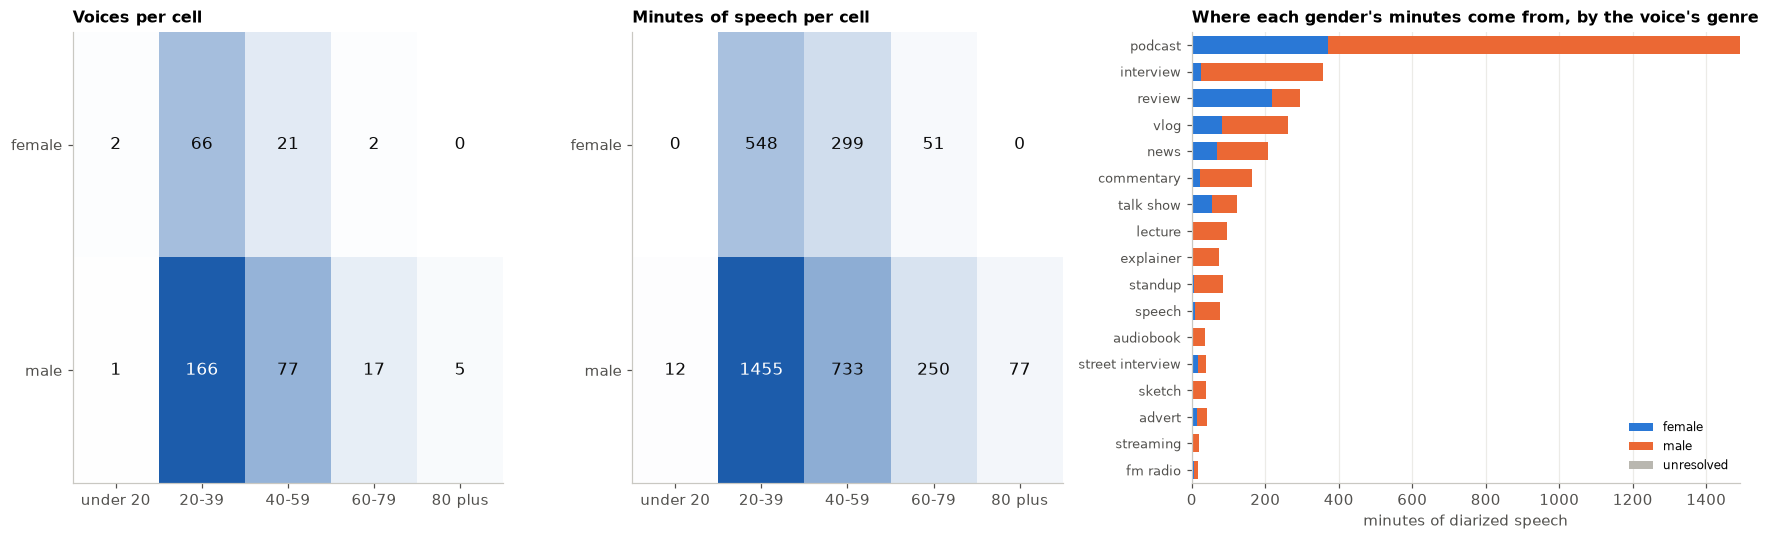

female speech: podcast holds 41% of it. Women hold 26% of the speech whose gender is known, from 0% (lecture) to 74% (review) across the 15 genres with 30+ such minutes: gender is confounded with genre, so every gender comparison below is also a genre comparison unless it is made within one genre.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.1, 1.1, 1.4]})
for ax, col, title in ((axes[0], "voices", "Voices per cell"), (axes[1], "minutes", "Minutes of speech per cell")):
    m = grid[col].unstack("age").reindex(GENDERS).reindex(columns=AGES)
    ax.imshow(m.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("blue", ["#ffffff", RAMP[3]]), aspect="auto")
    for i, g in enumerate(GENDERS):
        for j, a in enumerate(AGES):
            v = m.loc[g, a]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=11, color="white" if v > m.to_numpy().max() * 0.6 else INK)
    ax.set_xticks(range(len(AGES)), [pretty(a) for a in AGES])
    ax.set_yticks(range(len(GENDERS)), GENDERS)
    ax.set(title=title)
    ax.grid(False)

ax = axes[2]
by_genre = SPK.groupby(["genre", "gender"]).talk_min.sum().unstack(fill_value=0)
by_genre = by_genre.reindex([g for g in GENRES if g in by_genre.index]).reindex(columns=["female", "male", "unresolved"], fill_value=0)
left = np.zeros(len(by_genre))
for g in by_genre.columns:
    ax.barh(range(len(by_genre)), by_genre[g], left=left, color=GENDER_COLOR[g], label=g, height=0.68)
    left += by_genre[g].to_numpy()
ax.set_yticks(range(len(by_genre)), [pretty(g) for g in by_genre.index], fontsize=8.5)
ax.set_ylim(len(by_genre) - 0.5, -0.5)
ax.set(title="Where each gender's minutes come from, by the voice's genre", xlabel="minutes of diarized speech")
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save(fig, "01_voices_by_cell")
plt.show()
f_share = by_genre["female"] / by_genre["female"].sum()
known_min = by_genre[["female", "male"]]
f_in = (known_min.female / known_min.sum(axis=1))[known_min.sum(axis=1) >= 30]
print(f"female speech: {pretty(f_share.idxmax())} holds {f_share.max():.0%} of it. Women hold {known_min.female.sum() / known_min.to_numpy().sum():.0%} of the "
      f"speech whose gender is known, from {f_in.min():.0%} ({pretty(f_in.idxmin())}) to {f_in.max():.0%} ({pretty(f_in.idxmax())}) across the {len(f_in)} genres "
      f"with 30+ such minutes: gender is confounded with genre, so every gender comparison below is also a genre comparison unless it is made within one genre.")

## 3. Giving each voice its words

A clip's reference is one string, but a clip may hold two people. A clip's text is credited to a
voice only when that voice holds at least 90% of the clip's diarized talk; anything more shared
is left out of every per-voice measure. Tokens are the whitespace words of the reference with
edge punctuation removed, classified by script: **Devanagari** (Nepali), **Latin** (English),
**mixed** (a Latin stem carrying Devanagari morphology, *phoneमा*, *photosहरू*), numerals and
other. Fillers are kept, since *uh* versus *अँ* is itself a choice. Sentences are split on the
danda and on `.?!`.

In [5]:
DEV = re.compile(r"[ऀ-ॿ]")
LAT = re.compile(r"[A-Za-z]")
NUM = re.compile(r"^[0-9०-९.,%]+$")
EDGE = ".,;:!?।\"'()[]{}“”‘’-–—…"
SENT_END = re.compile(r"[।.?!]+")

EN_FUNCTION = set("""the a an is are was were be been being am to of and or but in on at for with that this these
those it its i you we they he she my your our their his her me us them not no do does did have has had will would
can could should shall may might if then so because what which who whom how there here as from by about just very
than too also any some all more most much many such there's it's that's i'm you're we're they're don't doesn't didn't
can't won't isn't aren't wasn't""".split())
EN_FILLER = {"uh", "um", "hmm", "mm", "ah", "er"}
HONORIFIC = {"high": ("तपाईं", "तपाई", "तपाईँ", "हजुर"), "mid": ("तिमी", "तिम्र"), "low": ("तँ", "तेर", "तैं", "तैँ")}
DM_NE = {"चाहिँ": "chāhī̃", "चैँ": "chāhī̃", "नि": "ni", "है": "hai", "अनि": "ani", "हैन": "haina", "भनेको": "bhaneko",
         "भन्या": "bhaneko", "मतलब": "matlab", "खै": "khai", "ल": "la"}
DM_EN = {"so", "like", "actually", "basically", "okay", "ok", "right", "yeah", "literally", "obviously", "anyway"}
DM_EN_BIGRAM = {("you", "know"), ("i", "mean")}


def sentences(text):
    out = []
    for sent in SENT_END.split(text):
        toks = []
        for w in sent.split():
            w = w.strip(EDGE)
            if not w:
                continue
            d, l = bool(DEV.search(w)), bool(LAT.search(w))
            toks.append((w, "mixed" if d and l else "dev" if d else "lat" if l else "num" if NUM.match(w) else "other"))
        if toks:
            out.append(toks)
    return out


def features(text):
    f = Counter()
    for sent in sentences(text):
        lex = [(w, c) for w, c in sent if c in ("dev", "lat", "mixed")]
        if not lex:
            continue
        kinds = {c for _, c in lex}
        f["sentences"] += 1
        f["s_nepali" if kinds == {"dev"} else "s_english" if "dev" not in kinds else "s_mixed"] += 1
        prev, run = None, 0
        for w, c in lex:
            f[c] += 1
            side = "en" if c != "dev" else "ne"
            if prev and side != prev:
                f["switches"] += 1
            if side == "en":
                run += 1
            elif run:
                if "dev" in kinds:
                    f[f"run_{min(run, 6)}"] += 1
                    f[f"run_tok_{min(run, 6)}"] += run
                run = 0
            prev = side
            lw = w.lower()
            if c == "lat":
                f["en_function"] += lw in EN_FUNCTION
                f["en_filler"] += lw in EN_FILLER
                f["dm_en"] += lw in DM_EN
                f["en_you"] += lw in ("you", "your", "yours", "you're")
            elif c == "dev":
                f["ne_filler"] += w in ("अँ", "अ", "ऊँ")
                for level, prefixes in HONORIFIC.items():
                    if w.startswith(prefixes):
                        f[f"hon_{level}"] += 1
                        f["hajur_bare"] += w == "हजुर"
                if w in DM_NE:
                    f["dm_ne"] += 1
                    f[f"dmne_{DM_NE[w]}"] += 1
        if run and "dev" in kinds:
            f[f"run_{min(run, 6)}"] += 1
            f[f"run_tok_{min(run, 6)}"] += run
        low = [w.lower() for w, c in lex]
        f["dm_en"] += sum((a, b) in DM_EN_BIGRAM for a, b in zip(low, low[1:]))
    f["tokens"] = f["dev"] + f["lat"] + f["mixed"]
    return dict(f)


feat = pd.DataFrame([features(t) for t in usable.text], index=usable.index).fillna(0).astype(int)
usable = usable.join(feat)
usable = usable[usable.tokens > 0]

dominant = {}
for sid, per in talk.items():
    if per and sid in usable.index:
        v, s = max(per.items(), key=lambda kv: kv[1])
        if s / sum(per.values()) >= 0.9:
            dominant[sid] = v
usable["speaker"] = pd.Series(dominant).reindex(usable.index)
attributed = usable[usable.speaker.notna()].copy()
for f in ("gender", "age", "role"):
    attributed[f] = attributed.speaker.map(SPK[f])

print(f"{len(usable):,} clips, {usable.tokens.sum():,} tokens ({usable.dev.sum() / usable.tokens.sum():.0%} Devanagari, "
      f"{usable.lat.sum() / usable.tokens.sum():.0%} Latin, {usable.mixed.sum() / usable.tokens.sum():.1%} mixed-script)")
print(f"{len(attributed):,} clips ({len(attributed) / len(usable):.0%}) and {attributed.tokens.sum() / usable.tokens.sum():.0%} of tokens "
      f"are credited to one voice; the rest are shared clips and stay out of per-voice measures")
print(f"sentences: {usable.s_nepali.sum() / usable.sentences.sum():.0%} Nepali only, {usable.s_mixed.sum() / usable.sentences.sum():.0%} mixed "
      f"within the sentence, {usable.s_english.sum() / usable.sentences.sum():.0%} English only")

COUNTS = [c for c in feat.columns]
V = attributed.groupby("speaker")[COUNTS].sum()
V = V.join(SPK[["talk_min", "episodes", "gender", "age", "role", "genre", "show"]])
V["english %"] = 100 * (V.lat + V.mixed) / V.tokens
V["switches / 100"] = 100 * V.switches / V.tokens
V["integrated / 1000"] = 1000 * V.mixed / V.tokens
V["en function %"] = 100 * V.en_function / V.lat.clip(lower=1)
V["single-word %"] = 100 * V.run_tok_1 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["long-run %"] = 100 * V.run_tok_6 / sum(V[f"run_tok_{k}"] for k in range(1, 7)).clip(lower=1)
V["en sentences %"] = 100 * V.s_english / V.sentences
for level in ("high", "mid", "low"):
    V[f"hon {level} / 1000"] = 1000 * V[f"hon_{level}"] / V.tokens
V["you / 1000"] = 1000 * V.en_you / V.tokens
V["dm ne / 1000"] = 1000 * V.dm_ne / V.tokens
V["dm en / 1000"] = 1000 * V.dm_en / V.tokens
V["en dm share %"] = 100 * V.dm_en / (V.dm_ne + V.dm_en).clip(lower=1)
V["rate w/s"] = attributed.groupby("speaker").tokens.sum() / attributed.groupby("speaker").speech_s.sum().clip(lower=1)
MIN_TOKENS = 300
VV = V[V.tokens >= MIN_TOKENS].copy()
# A genre is a group of voices only when three or more of them have most of their talk in it.
GENRE_GROUPS = [g for g in GENRES if (VV.genre == g).sum() >= 3]
print(f"{len(V)} voices carry attributed text; {len(VV)} have {MIN_TOKENS}+ tokens and are the units of every comparison below "
      f"(gender known for {(VV.gender != 'unresolved').sum()}, age {(VV.age != 'unresolved').sum()}, role {(VV.role != 'unresolved').sum()})")
print(f"{len(GENRE_GROUPS)} of {len(GENRES)} genres hold 3+ of those voices: " + ", ".join(f"{pretty(g)} {(VV.genre == g).sum()}" for g in GENRE_GROUPS))

17,591 clips, 594,892 tokens (77% Devanagari, 23% Latin, 0.5% mixed-script)
14,214 clips (81%) and 76% of tokens are credited to one voice; the rest are shared clips and stay out of per-voice measures
sentences: 43% Nepali only, 50% mixed within the sentence, 7% English only
294 voices carry attributed text; 171 have 300+ tokens and are the units of every comparison below (gender known for 171, age 171, role 105)
14 of 17 genres hold 3+ of those voices: podcast 48, interview 23, review 7, vlog 19, news 8, commentary 6, talk show 7, lecture 9, explainer 13, standup 7, speech 8, sketch 4, advert 5, streaming 3


## 4. Code-mixing across speakers

**First the groups, as they are.** Every dot is a voice with 300+ attributed tokens; the bar is
the group median. A genre is shown only when three or more such voices have most of their talk
time in it. The last two panels are the same gender and age splits inside the podcasts alone.
No test is attached to a panel: the groups differ in more than the one thing a panel names.
Older voices sit in the interviews, speeches and news, which are nearly all Nepali, so a
difference by age over the whole corpus is a difference by genre until genre is held fixed.

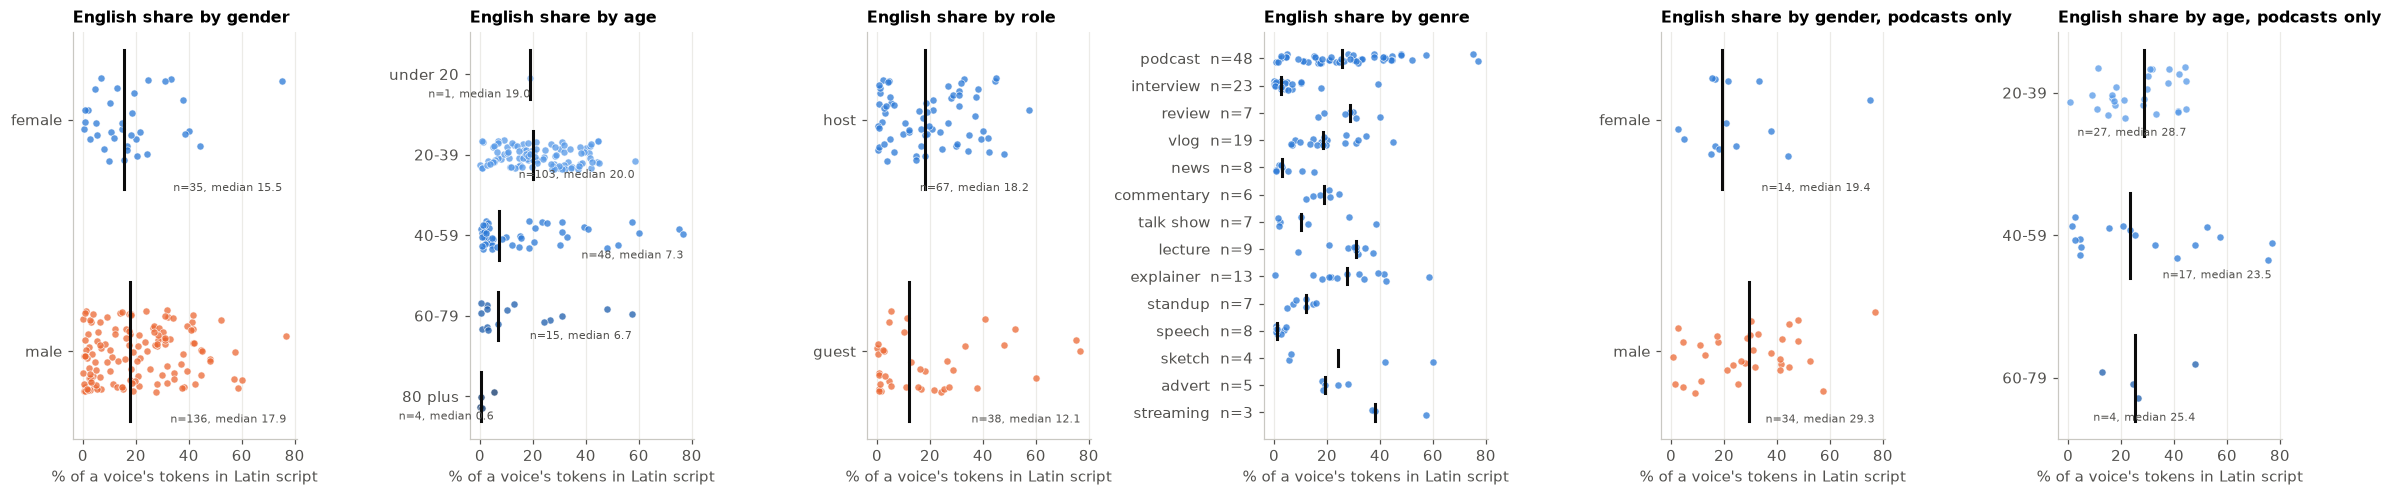

voices  minutes  english %  switches / 100  integrated / 1000  single-word %  long-run %  en function %  rate w/s
comparison               group                                                                                                                        
by gender                female       35.00   834.08      15.47           16.45               3.45          49.58        0.00           9.38      2.59
                         male        136.00 2,395.17      17.95           19.12               2.54          47.02        3.02           7.61      2.78
by age                   20_39       103.00 1,881.72      20.04           23.75               3.63          44.87        4.27           9.65      2.88
                         40_59        48.00   962.45       7.33            7.56               1.48          48.18        0.00           7.83      2.46
                         60_79        15.00   297.24       6.66            6.63               0.68          57.69        0.00           2.22      2.55
                         80_plus       4.00    75.41       0.55            1.10               0.16         100.00        0.00           0.00      2.22
by role                  host         67.00 1,693.57      18.16           17.93               3.00          47.06        3.66           7.87      2.64
                         guest        38.00   762.91      12.13           11.59               1.08          49.79        0.00           8.49      2.54
by genre                 podcast      48.00 1,467.72      25.82           21.43               4.33          39.74       10.43          19.98      2.85
                         interview    23.00   349.36       2.77            5.12               0.31          68.42        0.00           0.00      2.45
                         review        7.00   293.36      28.54           24.03               4.86          32.43        3.60           5.39      2.79
                         vlog         19.00   238.92      18.44           22.65               3.27          48.25        3.95           9.62      3.02
                         news          8.00   197.70       2.93            3.68               1.16          49.73        0.00           0.27      2.32
                         commentary    6.00   165.13      19.02           26.23               6.87          55.69        0.97           2.74      2.97
                         talk_show     7.00    73.35      10.10           15.27               0.00          58.33        0.00           5.59      2.74
                         lecture       9.00    95.19      30.96           28.14               5.04          38.52        9.09          13.78      2.69
                         explainer    13.00    65.93      27.46           30.75               5.07          35.84        0.00           5.56      2.97
                         standup       7.00    83.25      11.91           14.26               1.06          62.26        0.00           6.43      2.39
                         speech        8.00    74.85       1.08            1.81               0.11          72.56        0.00           2.17      2.41
                         sketch        4.00    34.71      24.20            7.98               4.51          41.60        7.14          33.42      2.33
                         advert        5.00    11.34      19.23           25.10               6.80          49.30        0.00           7.25      3.12
                         streaming     3.00    19.97      38.07           14.46               4.82          24.24       35.68          40.52      2.99
by gender, podcasts only female       14.00   368.69      19.38           23.91               5.26          48.64        5.31          15.39      2.54
                         male         34.00 1,099.03      29.28           20.25               3.24          34.24       13.94          25.87      2.90
by age, podcasts only    20_39        27.00   794.08      28.73           25.42               5.25          41.

In [6]:
def strip(ax, frame, col, by, order, colors, title=None, xlabel=None, min_n=1, compact=False):
    """One row of dots per group, with its median. ``compact`` is for many rows: the n moves into
    the row's label, where it cannot land on the next row's dots."""
    rng = np.random.default_rng(0)
    groups = [(g, frame.loc[frame[by] == g, col].dropna()) for g in order]
    groups = [(g, s) for g, s in groups if len(s) >= min_n]
    for i, (g, s) in enumerate(groups):
        ax.scatter(s, i + rng.uniform(-0.18, 0.18, len(s)), s=22, color=colors.get(g, GREY), alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.plot([s.median(), s.median()], [i - 0.3, i + 0.3], color=INK, lw=2)
        if not compact:
            ax.text(s.max(), i + 0.32, f"n={len(s)}, median {s.median():.1f}", fontsize=7.5, color=MUTED, ha="right", va="bottom")
    ax.set_yticks(range(len(groups)), [f"{pretty(g)}  n={len(s)}" if compact else pretty(g) for g, s in groups])
    ax.set(title=title or col, xlabel=xlabel or col)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    return groups


def test(frame, col, by, order):
    """Mann-Whitney or Kruskal-Wallis over the groups with three or more members. Used for the
    episode-level comparison of section 10 only: voices are compared by the models below."""
    groups = [frame.loc[frame[by] == g, col].dropna() for g in order if (frame[by] == g).sum() >= 3]
    if len(groups) < 2:
        return np.nan
    return (stats.mannwhitneyu(*groups).pvalue if len(groups) == 2 else stats.kruskal(*groups).pvalue)


pod = VV[VV.genre == "podcast"]
AGE_COLOR = dict(zip(AGES, RAMP[-len(AGES):]))
panels = [("gender", GENDERS, GENDER_COLOR, VV, "by gender"), ("age", AGES, AGE_COLOR, VV, "by age"),
          ("role", ROLES, ROLE_COLOR, VV, "by role"), ("genre", GENRE_GROUPS, GENRE_COLOR, VV, "by genre"),
          ("gender", GENDERS, GENDER_COLOR, pod, "by gender, podcasts only"), ("age", AGES, AGE_COLOR, pod, "by age, podcasts only")]
fig, axes = plt.subplots(1, 6, figsize=(21, 4.6), sharex=True)
for ax, (by, order, colors, frame, title) in zip(axes, panels):
    strip(ax, frame, "english %", by, order, colors, title=f"English share {title}", xlabel="% of a voice's tokens in Latin script",
          compact=by == "genre")
fig.tight_layout()
save(fig, "02_mixing_by_group")
plt.show()

METRICS = ["english %", "switches / 100", "integrated / 1000", "single-word %", "long-run %", "en function %", "rate w/s"]
tab = {}
for by, order, _, frame, title in panels:
    for g in order:
        sub = frame[frame[by] == g]
        if len(sub) >= 3:
            tab[(title, g)] = {"voices": len(sub), "minutes": sub.talk_min.sum(), **{m: sub[m].median() for m in METRICS}}
tab = pd.DataFrame(tab).T
tab.index.names = ["comparison", "group"]
display(tab.round(2))

**Then one model per measure, instead of a test per panel.** Each measure is regressed on age
(a step per twenty-year bracket), gender and genre at once, with a random intercept for the show
a voice mostly speaks on, so that ten guests of one podcast do not count as ten independent
draws. The switch rate and the speaking rate also take the voice's English share and its square:
a speaker at 50% English has more room to switch than one at 5%, and an English word is shorter
than a Nepali one, so the question for both is who differs *at the same share*. Role is known
for fewer voices, so it gets a second fit on those alone.

Read the table as: the coefficient is in the measure's own units, the interval is 95%, and
`Holm` is the p-value corrected for every coefficient in the table at once, which is the one to
quote. `p (ranks)` refits the measure as a normal score of its rank, because several of these
rates are far from normal; where the two p-values disagree the raw one is leaning on a few
extreme voices.

,,coefficient [95% CI],p,p (ranks),Holm,voices,shows,show share of variance
term,measure,,,,,,,
"age, per bracket",english %,"-0.63 [-3.78, +2.52]",0.69,0.24,1.00,171,97,0.16
female vs male,english %,"-0.38 [-5.64, +4.88]",0.89,0.96,1.00,171,97,0.16
"age, per bracket",switches / 100,"-1.24 [-2.35, -0.14]",0.03,0.06,0.62,171,97,0.18
female vs male,switches / 100,"+1.04 [-0.69, +2.76]",0.24,0.23,1.00,171,97,0.18
"age, per bracket",integrated / 1000,"-1.05 [-1.98, -0.12]",0.03,0.0083,0.62,171,97,0.76
female vs male,integrated / 1000,"+0.98 [-0.73, +2.70]",0.26,0.35,1.00,171,97,0.76
"age, per bracket",single-word %,"+4.85 [+0.35, +9.35]",0.03,0.07,0.73,171,97,0.13
female vs male,single-word %,"+2.22 [-5.49, +9.93]",0.57,0.51,1.00,171,97,0.13
"age, per bracket",long-run %,"+0.74 [-2.25, +3.74]",0.63,0.83,1.00,171,97,0.05


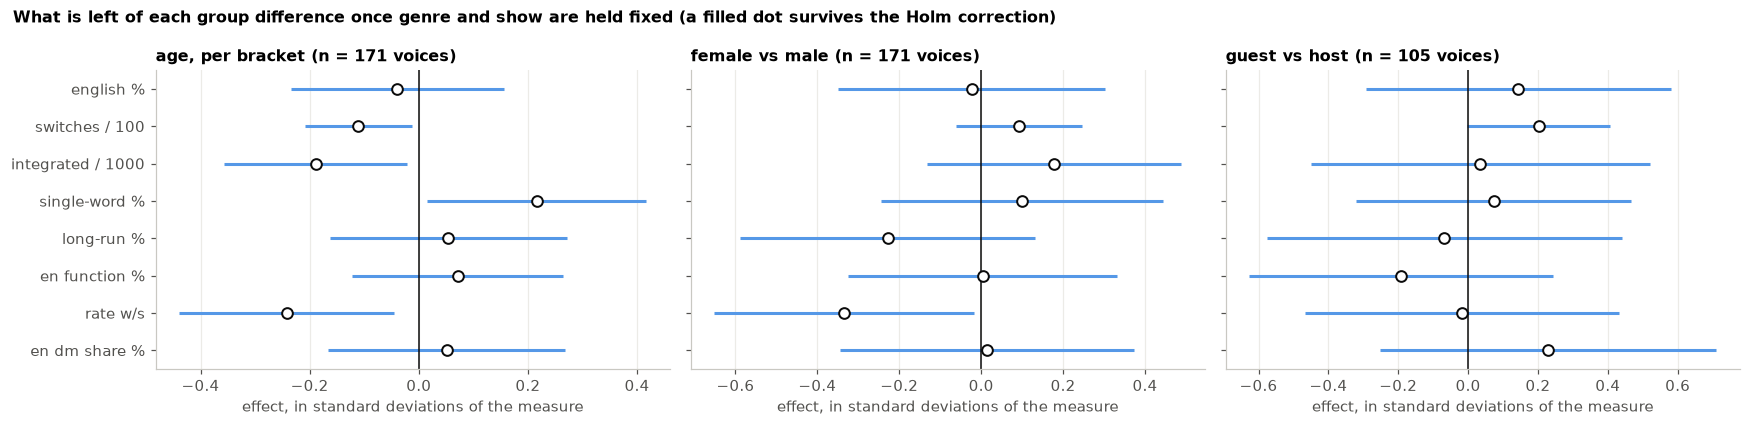

24 coefficients; 5 are under 0.05 on their own and 0 survive the correction: none


In [7]:
AGE_RANK = {a: i for i, a in enumerate(AGE_ORDER)}
MODEL_MEASURES = ["english %", "switches / 100", "integrated / 1000", "single-word %", "long-run %", "en function %", "rate w/s", "en dm share %"]


def model_frame(frame):
    """One row per voice with what the model conditions on. Genres too small to be a group are
    pooled, so no coefficient is fitted to one or two voices."""
    m = frame[frame.gender.isin(GENDERS) & frame.age.isin(AGE_RANK)].copy()
    m["age_r"] = m.age.map(AGE_RANK).astype(float)
    m["female"] = (m.gender == "female").astype(float)
    m["guest"] = (m.role == "guest").astype(float)
    m["genre_g"] = m.genre.where(m.genre.isin(GENRE_GROUPS), "other")
    m["eng"] = m["english %"]
    return m


def fit(m, measure, terms, genre=True, ranked=False):
    """``measure ~ terms (+ genre) + (1 | show)``. Falls back to ordinary least squares when the
    shows explain nothing and the mixed model cannot be fitted."""
    y = m[measure].astype(float)
    d = m.assign(y=stats.norm.ppf((y.rank() - 0.5) / len(y)) if ranked else y)
    formula = "y ~ " + " + ".join(terms) + (" + C(genre_g)" if genre and d.genre_g.nunique() > 1 else "")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            res = smf.mixedlm(formula, d, groups=d["show"]).fit(reml=True)
            icc = float(res.cov_re.iloc[0, 0] / (res.cov_re.iloc[0, 0] + res.scale))
        except Exception:
            res, icc = smf.ols(formula, d).fit(), 0.0
    return res, icc


def controlled(frame, terms_of, genre=True):
    """Every measure fitted with the same terms; one row per measure and term."""
    m, out = model_frame(frame), []
    for measure in MODEL_MEASURES:
        terms = terms_of(measure)
        res, icc = fit(m, measure, terms, genre)
        ranked, _ = fit(m, measure, terms, genre, ranked=True)
        ci = res.conf_int()
        for term in terms[:len(terms_of("english %"))]:   # the covariates of the switch rate are not findings
            out.append({"measure": measure, "term": term, "coef": res.params[term], "lo": ci.loc[term, 0], "hi": ci.loc[term, 1],
                        "p": res.pvalues[term], "p (ranks)": ranked.pvalues[term], "sd": m[measure].std(),
                        "voices": len(m), "shows": m.show.nunique(), "show share of variance": icc})
    return pd.DataFrame(out)


def holm(p):
    """Holm's step-down correction: the family-wise error rate over every p-value passed."""
    p = np.asarray(p, dtype=float)
    order = np.argsort(p)
    adj = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order])
    out = np.empty(len(p))
    out[order] = np.minimum(adj, 1.0)
    return out


#: Measures that move with the English share by arithmetic alone: there is more room to switch at
#: 50% English than at 5%, and an English word is shorter than a Nepali one.
AT_THE_SAME_SHARE = ("switches / 100", "rate w/s")


def with_share(base):
    return lambda measure: base + (["eng", "I(eng ** 2)"] if measure in AT_THE_SAME_SHARE else [])


MODELS = pd.concat([
    controlled(VV, with_share(["age_r", "female"])),
    controlled(VV[VV.role.isin(ROLES)], with_share(["guest", "age_r", "female"])).query("term == 'guest'"),
], ignore_index=True)
MODELS["Holm"] = holm(MODELS.p)
MODELS["term"] = MODELS.term.map({"age_r": "age, per bracket", "female": "female vs male", "guest": "guest vs host"})


def model_row(measure, term):
    return MODELS[(MODELS.measure == measure) & (MODELS.term == term)].iloc[0]


def small(p):
    return "< 0.0001" if p < 0.0001 else f"= {p:.4f}" if p < 0.01 else f"= {p:.2f}"


shown = MODELS.assign(**{"coefficient [95% CI]": [f"{r.coef:+.2f} [{r.lo:+.2f}, {r.hi:+.2f}]" for r in MODELS.itertuples()],
                         **{c: MODELS[c].map(lambda p: small(p).lstrip("= ")) for c in ("p", "p (ranks)", "Holm")}})
display(shown.set_index(["term", "measure"])[["coefficient [95% CI]", "p", "p (ranks)", "Holm", "voices", "shows", "show share of variance"]])

TERMS = ["age, per bracket", "female vs male", "guest vs host"]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), sharey=True)
for ax, term in zip(axes, TERMS):
    sub = MODELS[MODELS.term == term].set_index("measure").reindex(MODEL_MEASURES)
    y = np.arange(len(sub))
    ax.hlines(y, sub.lo / sub.sd, sub.hi / sub.sd, color=RAMP[1], lw=2)
    kept = (sub.Holm < 0.05).to_numpy()
    ax.plot((sub.coef / sub.sd)[kept], y[kept], "o", ms=7, color=INK, mec="white", mew=1, zorder=3)
    ax.plot((sub.coef / sub.sd)[~kept], y[~kept], "o", ms=7, color="white", mec=INK, mew=1.3, zorder=3)
    ax.axvline(0, color=INK, lw=1)
    ax.set_yticks(y, MODEL_MEASURES)
    ax.set_ylim(len(sub) - 0.5, -0.5)
    ax.set(title=f"{term} (n = {int(sub.voices.iloc[0])} voices)", xlabel="effect, in standard deviations of the measure")
    ax.grid(axis="y", visible=False)
fig.suptitle("What is left of each group difference once genre and show are held fixed (a filled dot survives the Holm correction)",
             x=0.01, ha="left", fontsize=10.5, fontweight="bold")
fig.tight_layout()
save(fig, "02b_controlled")
plt.show()
kept = MODELS[MODELS.Holm < 0.05]
print(f"{len(MODELS)} coefficients; {int((MODELS.p < 0.05).sum())} are under 0.05 on their own and {len(kept)} survive the correction: "
      + ("; ".join(f"{r.measure} by {r.term} ({r.coef:+.2f}, Holm p {small(r.Holm)})" for r in kept.itertuples()) or "none"))

**How far the age effect on switching can be pushed.** The panels above suggest nothing about
people more strongly than this: younger speakers switch more often. Over all voices the model
finds it, but not at the corrected level. A pooled model is a hard place for it, though: in the
genres that are nearly all Nepali the switch rate is near zero for everyone, whatever their age.
So it is tried where there is English to switch into, and four more ways: inside the podcasts
alone; among guests only, since a series' host is one person heard many times; on the clips
that were played and read rather than screened, because a switch is counted from the script of
each word and that is what the recognisers disagree on; and with each show left out in turn, to
see whether one show carries it. These are follow-ups chosen after looking, so they say the
effect is worth a planned test, not that it has passed one.

In [8]:
def age_on_switching(frame, genre=True):
    m = model_frame(frame)
    res, _ = fit(m, "switches / 100", ["age_r", "female", "eng", "I(eng ** 2)"], genre)
    lo, hi = res.conf_int().loc["age_r"]
    return {"voices": len(m), "shows": m.show.nunique(), "switches / 100 per bracket": res.params["age_r"], "lo": lo, "hi": hi, "p": res.pvalues["age_r"]}


# Per-voice rates again, from the clips a person played and read.
ver = attributed[attributed.tier == "verified"].groupby("speaker")[["tokens", "lat", "mixed", "switches"]].sum()
ver = ver[ver.tokens >= MIN_TOKENS].join(SPK[["gender", "age", "role", "genre", "show"]])
ver["english %"] = 100 * (ver.lat + ver.mixed) / ver.tokens
ver["switches / 100"] = 100 * ver.switches / ver.tokens

checks = {
    "all voices": age_on_switching(VV),
    "podcasts only": age_on_switching(pod, genre=False),
    "guests only": age_on_switching(VV[VV.role == "guest"]),
    "verified clips only": age_on_switching(ver),
    "verified clips, podcasts only": age_on_switching(ver[ver.genre == "podcast"], genre=False),
}
checks_t = pd.DataFrame(checks).T.astype({"voices": int, "shows": int})
display(checks_t.assign(p=checks_t.p.map(lambda p: small(p).lstrip("= "))))
loo = pd.Series({s: age_on_switching(VV[VV.show != s])["switches / 100 per bracket"] for s, n in VV.show.value_counts().items() if n >= 3})
print(f"leaving out each of the {len(loo)} shows with 3+ usable voices in turn, the age coefficient stays between {loo.min():+.2f} and {loo.max():+.2f} "
      f"(all voices: {checks['all voices']['switches / 100 per bracket']:+.2f}); the show whose removal moves it most is {(loo - checks['all voices']['switches / 100 per bracket']).abs().idxmax()}")

,voices,shows,switches / 100 per bracket,lo,hi,p
all voices,171,97,-1.24,-2.35,-0.14,0.03
podcasts only,48,17,-4.27,-6.69,-1.84,0.0006
guests only,38,13,-3.91,-6.51,-1.31,0.0032
verified clips only,68,51,-2.59,-4.28,-0.90,0.0027
"verified clips, podcasts only",23,9,-3.82,-6.01,-1.64,0.0006


leaving out each of the 14 shows with 3+ usable voices in turn, the age coefficient stays between -1.74 and -0.71 (all voices: -1.24); the show whose removal moves it most is sanjay_silwal_gupta


## 5. How the English gets in

Three readings that a paper on mixing would want, each of which the transcript supports:

- **Insertion vs alternation** (Muysken's distinction): inside a mixed sentence, how long is a
  stretch of English? A single English word sitting in a Nepali clause is a lexical insertion;
  six or more in a row is a switch into English syntax. The share of English tokens that sit in
  each run length says which of the two this corpus mostly is.
- **Morphological integration**: an English stem taking Nepali plural or case morphology
  (*phonesहरूको*, *Chinaमा*) is the clearest sign of a borrowing that has entered the Nepali
  grammar. The most frequent such tokens are listed, with the Nepali suffixes they take.
- **English function words** as a share of a voice's English: a speaker who inserts nouns has
  almost none; a speaker who switches into English clauses carries *the, is, to, and* with them.

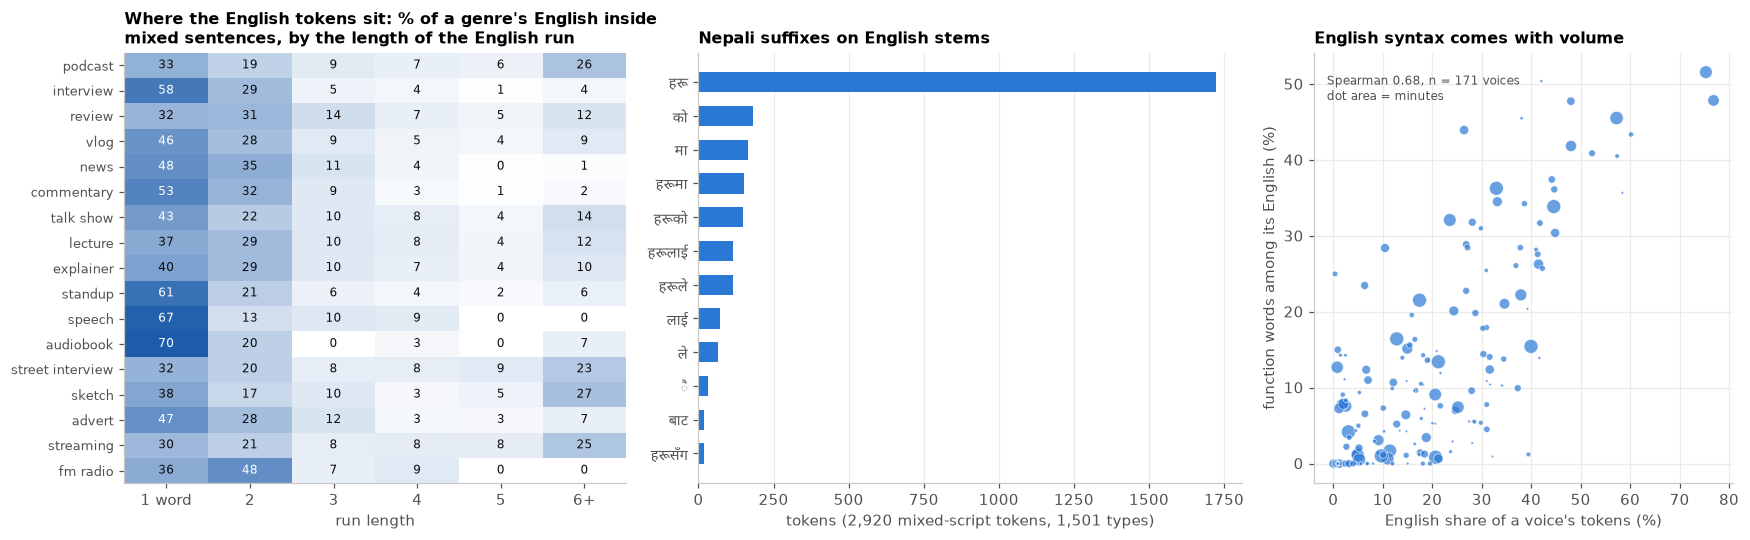

most frequent integrated stems: phoneको (83), phoneमा (57), videoमा (40), photosहरू (30), videoहरू (29), phonesहरू (28), foodहरू (28), companyको (22), lastै (20), companyले (19), questionहरू (19), Americaमा (17), portraitsहरू (17), phonesहरूमा (17), phoneहरू (16)
37% of the English inside mixed sentences is a single word; 18% sits in runs of six or more; 7% of sentences are entirely English


In [9]:
run_cols = [f"run_tok_{k}" for k in range(1, 7)]
RUN_LABELS = ["1 word", "2", "3", "4", "5", "6+"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.2, 1.3, 1]})
ax = axes[0]
runs = usable.groupby("genre")[run_cols].sum().reindex(GENRES)
run_share = 100 * runs.div(runs.sum(axis=1), axis=0)
ax.imshow(run_share.to_numpy(), cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("blue", ["#ffffff", RAMP[3]]), aspect="auto", vmin=0)
for i in range(run_share.shape[0]):
    for j in range(run_share.shape[1]):
        v = run_share.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > np.nanmax(run_share.to_numpy()) * 0.6 else INK)
ax.set_xticks(range(6), RUN_LABELS)
ax.set_yticks(range(len(GENRES)), [pretty(g) for g in GENRES], fontsize=8.5)
ax.set(title="Where the English tokens sit: % of a genre's English inside\nmixed sentences, by the length of the English run", xlabel="run length")
ax.grid(False)

ax = axes[1]
suffix = Counter()
integrated = Counter()
for text in usable.text:
    for w in text.split():
        w = w.strip(EDGE)
        if DEV.search(w) and LAT.search(w):
            integrated[w] += 1
            m = re.match(r"^([A-Za-z'\-]+)([ऀ-ॿ]+)$", w)
            if m:
                suffix[m.group(2)] += 1
top = pd.Series(suffix).sort_values(ascending=False).head(12)
ax.barh(top.index[::-1], top[::-1], color=RAMP[2], height=0.6)
ax.set_yticks(range(len(top)))
script_aware(ax.set_yticklabels(top.index[::-1]))
ax.set(title="Nepali suffixes on English stems", xlabel=f"tokens ({sum(integrated.values()):,} mixed-script tokens, {len(integrated):,} types)")
ax.grid(axis="y", visible=False)

ax = axes[2]
ax.scatter(VV["english %"], VV["en function %"], s=VV.talk_min.clip(2, 60) * 1.4, color=SLOTS[0], alpha=0.7, edgecolor="white", linewidth=0.5)
ax.set(title="English syntax comes with volume", xlabel="English share of a voice's tokens (%)", ylabel="function words among its English (%)")
rho = stats.spearmanr(VV["english %"], VV["en function %"])[0]
ax.text(0.03, 0.95, f"Spearman {rho:.2f}, n = {len(VV)} voices\ndot area = minutes", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)
fig.tight_layout()
save(fig, "03_how_english_enters")
plt.show()
print("most frequent integrated stems:", ", ".join(f"{w} ({n})" for w, n in integrated.most_common(15)))
tot_runs = usable[run_cols].sum().sum()
print(f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of the English inside mixed sentences is a single word; "
      f"{100 * usable.run_tok_6.sum() / tot_runs:.0f}% sits in runs of six or more; {100 * usable.s_english.sum() / usable.sentences.sum():.0f}% of sentences are entirely English")

## 6. The moment of the switch

Sections 4 and 5 count switches. This one looks at what happens *at* one: which words carry it,
whether the speaker pauses before it, and whether the speech around it speeds up or slows down.

**What the timing rests on.** Every label carries its words with a start and an end (D108). For
a label accepted unchanged they are the fused seed's words as the harness's forced aligner placed
them on the audio; an edited label is aligned again on its own clip. The aligner works in 20 ms
frames, so no single boundary is known better than that, and against the one recogniser that
reports its own word timings a boundary differs by a few tens of milliseconds (printed below).
That is too coarse to say anything about one pause and ample for the average of thousands: a
pause a listener hears is 200 ms or more, ten frames. To check that the result is not the
aligner's, the pause analysis is run twice: on the label's words, and on that recogniser's own
words with its own timings, which share neither the text nor the clock.

**What counts as a switch here.** Two neighbouring words in different scripts. Only boundaries
written as a plain space are timed: a comma or a sentence end is a pause for another reason, and
a Nepali suffix written onto an English stem (*phone·को*) is one word said in one breath. A
numeral is neither language and ends the comparison on both sides.

17,590 of 17,591 clips have timed label words ({'missing': 69, 'realigned': 103, 'seed': 17487}): 606,386 words, 122,030 changes of language between neighbours
resolution: the gaps the aligner reports most often are 20, 40, 60 ms, steps of its 20 ms frame. Against elevenlabs-scribe-v2's own timings a word's start differs by 37 ms on average and its end by 66 ms; 87% of words agree within 100 ms


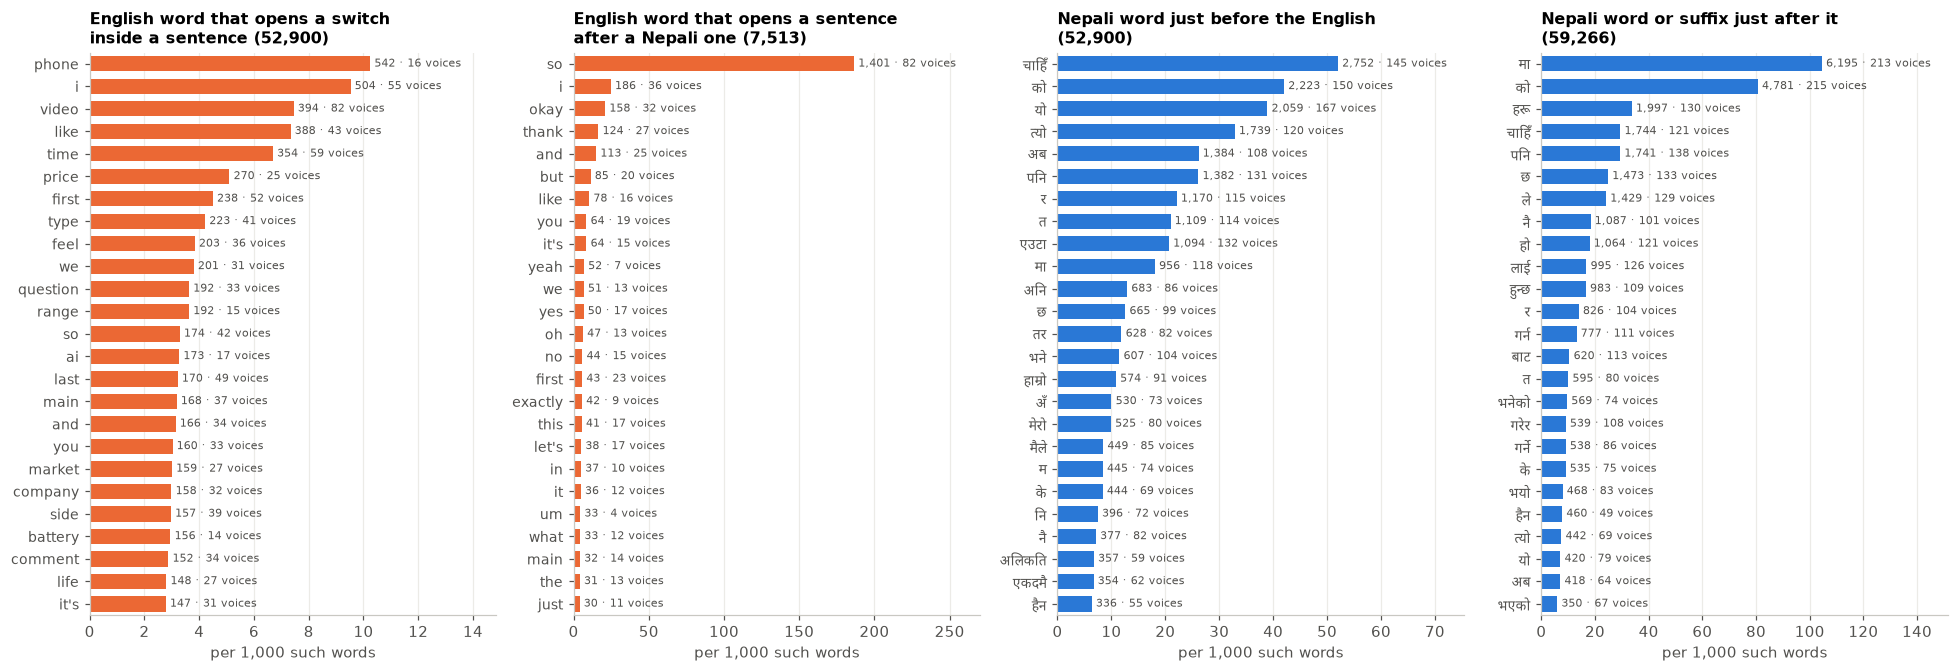

52,900 switches into English inside a sentence use 7,059 different words: the 10 commonest are 6% of them, the 100 commonest 24%, and 38% of the words are used once. 68% of these switches are one word long.
after the English: 5% of the time a suffix written onto the stem, 10% a form of गर्नु ('to do'), which is how an English verb or noun is made to work as a Nepali verb


In [10]:
TOKEN = re.compile(r"[A-Za-z0-9']+|[ऀ-ॣ०-ॿ]+")   # how the export cuts a label into its timed words
DEV_LETTER = re.compile(r"[ऀ-ॣॱ-ॿ]")


def kind(word):
    return "en" if LAT.search(word) else "ne" if DEV_LETTER.search(word) else "num"


def separator(between):
    """What stands between two words: nothing (a suffix written onto a stem), a space, a comma or
    other mark, or the end of a sentence."""
    if between == "":
        return "joined"
    if re.search(r"[।॥.?!]", between):
        return "sentence"
    return "space" if between.strip() == "" else "comma"


def label_words(sid, text):
    """The label's words with their spans and what follows each. None when the export could not
    time them."""
    timed, found = LABEL_WORDS.get(sid), list(TOKEN.finditer(text))
    if not timed or [m.group(0) for m in found] != [w["word"] for w in timed]:
        return None
    return [(w["word"], w["start"], w["end"], separator(text[m.end():found[i + 1].start()]) if i + 1 < len(found) else "end")
            for i, (m, w) in enumerate(zip(found, timed))]


def scribe_words(sid, text=None):
    """The same from one recogniser's own words and its own timings. Its punctuation rides on the
    word, and a word it wrote in two scripts is one span."""
    out = []
    for x in SCRIBE_WORDS.get(sid) or []:
        pieces = TOKEN.findall(x["word"])
        if x["start"] is None or x["end"] is None or not pieces:
            continue
        tail = x["word"][x["word"].rfind(pieces[-1]) + len(pieces[-1]):]
        out += [(p, x["start"], x["end"], "joined" if j < len(pieces) - 1 else separator(tail) if tail else "space")
                for j, p in enumerate(pieces)]
    return out or None


def word_table(words_of):
    """One row per word, with its neighbours: what the questions below are asked of."""
    rows = []
    for sid, text in zip(usable.index, usable.text):
        words = words_of(sid, text)
        if not words:
            continue
        kinds = [kind(w[0]) for w in words]
        for i, (w, start, end, sep) in enumerate(words):
            rows.append((sid, dominant.get(sid), w.lower() if kinds[i] == "en" else w, kinds[i], end - start, sep,
                         kinds[i - 1] if i else None, words[i - 1][3] if i else None, start - words[i - 1][2] if i else np.nan,
                         kinds[i + 1] if i + 1 < len(words) else None, words[i - 1][0] if i else None,
                         words[i + 1][0] if i + 1 < len(words) else None))
    return pd.DataFrame(rows, columns=["seg", "voice", "word", "kind", "dur", "sep_after", "prev_kind", "sep_before", "gap",
                                       "next_kind", "prev_word", "next_word"])


W = word_table(label_words)
report = json.loads((ANALYTICS.parent / "timestamp_verification_report.json").read_text())
steps = sorted(pd.Series(np.round(1000 * W.gap[W.gap > 0.001])).value_counts().head(3).index.astype(int))
print(f"{W.seg.nunique():,} of {len(usable):,} clips have timed label words ({manifest['label_words']}): {len(W):,} words, "
      f"{int(((W.kind != W.prev_kind) & W.kind.isin(['ne', 'en']) & W.prev_kind.isin(['ne', 'en'])).sum()):,} changes of language between neighbours")
print(f"resolution: the gaps the aligner reports most often are {', '.join(map(str, steps))} ms, steps of its 20 ms frame. Against {report['reference_system_id']}'s own timings a word's start "
      f"differs by {report['mae_start_ms']:.0f} ms on average and its end by {report['mae_end_ms']:.0f} ms; {report['rate_within_100ms']:.0f}% of words agree within 100 ms")

inside = W.sep_before.isin(["space", "comma"])
switch_in = W[(W.kind == "en") & (W.prev_kind == "ne") & inside]
opens_sentence = W[(W.kind == "en") & (W.prev_kind == "ne") & (W.sep_before == "sentence")]
before = W[(W.kind == "ne") & (W.next_kind == "en") & W.sep_after.isin(["space", "comma"])]
after = W[(W.kind == "ne") & (W.prev_kind == "en") & W.sep_before.isin(["space", "comma", "joined"])]


def top(frame, n):
    t = frame.groupby("word").agg(count=("word", "size"), voices=("voice", "nunique")).sort_values("count", ascending=False).head(n)
    t["per 1000"] = 1000 * t["count"] / len(frame)
    return t


fig, axes = plt.subplots(1, 4, figsize=(18, 6.2))
for ax, (frame, n, color, title) in zip(axes, (
        (switch_in, 25, SLOTS[1], f"English word that opens a switch\ninside a sentence ({len(switch_in):,})"),
        (opens_sentence, 25, SLOTS[1], f"English word that opens a sentence\nafter a Nepali one ({len(opens_sentence):,})"),
        (before, 25, SLOTS[0], f"Nepali word just before the English\n({len(before):,})"),
        (after, 25, SLOTS[0], f"Nepali word or suffix just after it\n({len(after):,})"))):
    t = top(frame, n)
    ax.barh(range(len(t)), t["per 1000"], color=color, height=0.68)
    for y, r in enumerate(t.itertuples()):
        ax.text(r[3] + t["per 1000"].max() * 0.015, y, f"{r.count:,} · {r.voices} voices", va="center", fontsize=7, color=MUTED)
    ax.set_yticks(range(len(t)))
    script_aware(ax.set_yticklabels(t.index, fontsize=9))
    ax.set_ylim(len(t) - 0.5, -0.5)
    ax.set_xlim(0, t["per 1000"].max() * 1.45)
    ax.set(title=title, xlabel="per 1,000 such words")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "03b_switch_words")
plt.show()

types = switch_in.word.value_counts()
single = (switch_in.next_kind != "en") | ~switch_in.sep_after.isin(["space", "comma"])
print(f"{len(switch_in):,} switches into English inside a sentence use {len(types):,} different words: the 10 commonest are {100 * types.head(10).sum() / len(switch_in):.0f}% of them, "
      f"the 100 commonest {100 * types.head(100).sum() / len(switch_in):.0f}%, and {100 * (types == 1).sum() / len(types):.0f}% of the words are used once. "
      f"{100 * single.mean():.0f}% of these switches are one word long.")
garnu = after.word.str.startswith(("गर", "गरि", "गरे", "गर्")).mean()
print(f"after the English: {100 * (after.sep_before == 'joined').mean():.0f}% of the time a suffix written onto the stem, "
      f"{100 * garnu:.0f}% a form of गर्नु ('to do'), which is how an English verb or noun is made to work as a Nepali verb")

**Is there a hesitation before the switch, or an ease after it?** The gap between two
neighbouring words, by what the two are. The unit is the voice: each voice's mean gap and its
share of gaps of 200 ms or more at each kind of boundary, compared with the same voice's
Nepali-to-Nepali boundaries, for every voice with 30 boundaries of each kind.

Two things could fake a longer gap before English. One is the instrument, which is why the
second row set repeats it with another recogniser's words and timings. The other is the word: a
switch usually brings in a content word, and a speaker may pause before a rare noun in any
language. So the comparison is made once more with the word held fixed: the gap before the *same*
English word when it follows a Nepali word and when it follows an English one, and the gap before
the same Nepali word when it follows English and when it follows Nepali. The second of these also
takes out a spelling habit: *मा* and *को* are written onto a Nepali noun and after an English
one, so English-to-Nepali boundaries are full of suffixes that no Nepali-to-Nepali boundary
holds.

voices  mean gap ms  gaps of 200+ ms % gap vs Nepali→Nepali, ms voices with a longer gap %         p  \
timings                       boundary                                                                                                                  
label words, forced aligner   Nepali → Nepali       100        74.80               7.20                                                                 
                              Nepali → English      100       128.70              16.50                    48.90                     100.00  < 0.0001   
                              English → English     100        73.60               6.10                    -3.10                      45.00      0.27   
                              English → Nepali      100        54.10               3.90                   -19.20                      14.00  < 0.0001   
elevenlabs-scribe-v2, its own Nepali → Nepali        96        78.80               6.50                                                                 
                              Nepali → English       96       119.20              15.30                    37.50                      99.00  < 0.0001   
                              English → English      96        77.50               5.00                    -0.90                      47.90      0.80   
                              English → Nepali       96        68.20               4.70                    -8.50                      24.00  < 0.0001   

                                                long gaps vs Nepali→Nepali, points  
timings                       boundary                                              
label words, forced aligner   Nepali → Nepali                                       
                              Nepali → English                                7.90  
                              English → English                              -1.00  
                              English → Nepali                               -2.60  
elevenlabs-scribe-v2, its own Nepali → Nepali                                       
                              Nepali → English                                7.40  
                              English → English                              -1.30  
                              English → Nepali                               -1.60

,words,difference ms,lo,hi,words where it is longer %,p
"the same English word: after Nepali, minus after English",260,41.70,35.20,48.10,87.70,< 0.0001
"the same Nepali word: after English, minus after Nepali",235,-6.70,-10.10,-3.40,33.20,< 0.0001


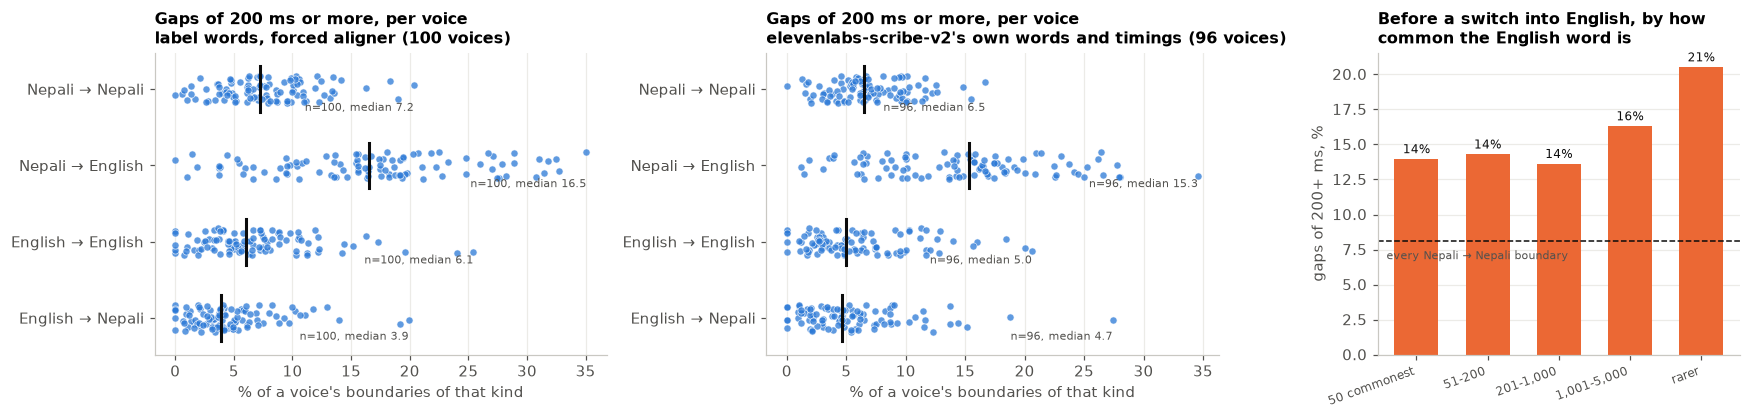

,switches,mean gap ms,gaps of 200+ ms %
English word,,,
50 commonest,5295,122.10,14.00
51-200,7918,120.60,14.30
"201-1,000",16796,119.60,13.60
"1,001-5,000",15245,129.80,16.30
rarer,2801,157.20,20.50


a filler (uh, um, अँ ...) stands right before 10.5 in 1,000 English words; 6.1 in 1,000 Nepali words


In [11]:
BOUNDARY = {("ne", "ne"): "Nepali → Nepali", ("ne", "en"): "Nepali → English", ("en", "en"): "English → English", ("en", "ne"): "English → Nepali"}
LONG = 0.2  # a silent pause a listener hears


def boundaries(table):
    b = table[(table.sep_before == "space") & table.kind.isin(["ne", "en"]) & table.prev_kind.isin(["ne", "en"])]
    return b.assign(boundary=[BOUNDARY[k] for k in zip(b.prev_kind, b.kind)], long=b.gap >= LONG)


def by_voice(b, min_n=30):
    """Each voice's mean gap and share of long gaps per kind of boundary, for the voices with
    ``min_n`` boundaries of every kind."""
    g = b[b.voice.notna()].groupby(["voice", "boundary"]).agg(n=("gap", "size"), ms=("gap", lambda x: 1000 * x.mean()), long=("long", lambda x: 100 * x.mean()))
    wide = g.unstack("boundary")
    return wide[(wide["n"] >= min_n).all(axis=1)]


def against_baseline(wide, name):
    base, rows = "Nepali → Nepali", []
    for kind_ in BOUNDARY.values():
        row = {"timings": name, "boundary": kind_, "voices": len(wide), "mean gap ms": wide["ms"][kind_].median(), "gaps of 200+ ms %": wide["long"][kind_].median()}
        if kind_ != base:
            d_ms, d_long = wide["ms"][kind_] - wide["ms"][base], wide["long"][kind_] - wide["long"][base]
            row.update({"gap vs Nepali→Nepali, ms": d_ms.median(), "voices with a longer gap %": 100 * (d_ms > 0).mean(), "p": stats.wilcoxon(d_ms).pvalue,
                        "long gaps vs Nepali→Nepali, points": d_long.median()})
        rows.append(row)
    return rows


def same_word(table, a, b, value="gap", key="prev_kind", k=20, seed=0):
    """``value`` of the same word in context ``a`` minus context ``b``, over the words seen ``k``
    times in each; weighted by the smaller count, with an interval that resamples words."""
    g = table[table[key].isin([a, b])].groupby(["word", key])[value].agg(["mean", "size"]).unstack(key)
    g = g[(g["size"][a] >= k) & (g["size"][b] >= k)]
    d, w = 1000 * (g["mean"][a] - g["mean"][b]).to_numpy(), g["size"].min(axis=1).to_numpy()
    pick = np.random.default_rng(seed).integers(0, len(d), size=(2000, len(d)))
    lo, hi = np.percentile((d[pick] * w[pick]).sum(axis=1) / w[pick].sum(axis=1), [2.5, 97.5])
    return {"words": len(d), "difference ms": np.average(d, weights=w), "lo": lo, "hi": hi, "words where it is longer %": 100 * (d > 0).mean(), "p": stats.wilcoxon(d).pvalue}


B = boundaries(W)
B_scribe = boundaries(word_table(scribe_words))
voices_l, voices_s = by_voice(B), by_voice(B_scribe)
PAUSES = pd.DataFrame(against_baseline(voices_l, "label words, forced aligner") + against_baseline(voices_s, f"{SCRIBE}, its own")).set_index(["timings", "boundary"])
display(PAUSES.assign(p=PAUSES.p.map(lambda p: "" if pd.isna(p) else small(p).lstrip("= "))).round(1).fillna(""))

en_in = B[B.kind == "en"]
ne_in = B[B.kind == "ne"]
FIXED = pd.DataFrame({
    "the same English word: after Nepali, minus after English": same_word(en_in, "ne", "en"),
    "the same Nepali word: after English, minus after Nepali": same_word(ne_in, "en", "ne"),
}).T
display(FIXED.assign(p=FIXED.p.map(lambda p: small(p).lstrip("= "))).astype({"words": int}).round(1))

# The gap before a switch, by how common the English word is: a hesitation should grow with rarity,
# an artefact of the aligner should not care.
rank = W[W.kind == "en"].word.value_counts().rank(ascending=False, method="first")
RARITY = [(0, 50, "50 commonest"), (50, 200, "51-200"), (200, 1000, "201-1,000"), (1000, 5000, "1,001-5,000"), (5000, np.inf, "rarer")]
sw = B[B.boundary == "Nepali → English"].assign(rank=lambda f: f.word.map(rank))
by_rarity = pd.DataFrame([{"English word": name, "switches": int(((sw["rank"] > lo) & (sw["rank"] <= hi)).sum()),
                           "mean gap ms": 1000 * sw.gap[(sw["rank"] > lo) & (sw["rank"] <= hi)].mean(),
                           "gaps of 200+ ms %": 100 * sw.long[(sw["rank"] > lo) & (sw["rank"] <= hi)].mean()} for lo, hi, name in RARITY]).set_index("English word")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [1.25, 1.25, 1]})
for ax, wide, name in ((axes[0], voices_l, "label words, forced aligner"), (axes[1], voices_s, f"{SCRIBE}'s own words and timings")):
    long = wide["long"].reset_index().melt(id_vars="voice", var_name="boundary", value_name="long")
    strip(ax, long, "long", "boundary", list(BOUNDARY.values()), dict.fromkeys(BOUNDARY.values(), SLOTS[0]),
          title=f"Gaps of 200 ms or more, per voice\n{name} ({len(wide)} voices)", xlabel="% of a voice's boundaries of that kind")
ax = axes[2]
ax.bar(range(len(by_rarity)), by_rarity["gaps of 200+ ms %"], color=SLOTS[1], width=0.62)
ax.axhline(100 * B.long[B.boundary == "Nepali → Nepali"].mean(), color=INK, lw=1, ls="--")
ax.text(-0.42, 100 * B.long[B.boundary == "Nepali → Nepali"].mean() - 1.3, "every Nepali → Nepali boundary", ha="left", fontsize=7.5, color=MUTED)
for x, r in enumerate(by_rarity.itertuples()):
    ax.text(x, r[3] + 0.4, f"{r[3]:.0f}%", ha="center", fontsize=8, color=INK)
ax.set_xticks(range(len(by_rarity)), by_rarity.index, fontsize=8, rotation=20, ha="right")
ax.set(title="Before a switch into English, by how\ncommon the English word is", ylabel="gaps of 200+ ms, %")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "03c_switch_pauses")
plt.show()
display(by_rarity.round(1))

FILLERS = {"uh", "um", "hmm", "mm", "ah", "er", "अँ", "अ", "ऊँ", "आ"}
lex = W[W.kind.isin(["ne", "en"]) & W.prev_word.notna()]
filled = lex.prev_word.str.lower().isin(FILLERS).groupby(lex.kind).agg(["sum", "size"])
print("a filler (uh, um, अँ ...) stands right before " + "; ".join(
    f"{1000 * r['sum'] / r['size']:.1f} in 1,000 {name} words" for name, r in (("English", filled.loc["en"]), ("Nepali", filled.loc["ne"]))))

**Which English words is the hesitation strongest and weakest before?** The average above
hides a wide spread between words. For every English word that opens 30 or more switches from
at least 8 voices (so that no one speaker's habit makes the list), the mean silent gap before it
when a Nepali word comes just before, with an interval that resamples its occurrences. Two
baselines: the gap between any two neighbouring words, whatever their languages, and the gap
before every English word that follows a Nepali one. The hollow marker is the same word after an
English word, where it has 10 or more such occurrences: a word that is slow to start only after
Nepali is slow because of the switch, not because of the word.

The list is ranked by an estimate with an interval, so a word's place in it is loose: read the
two ends, not the order within them.

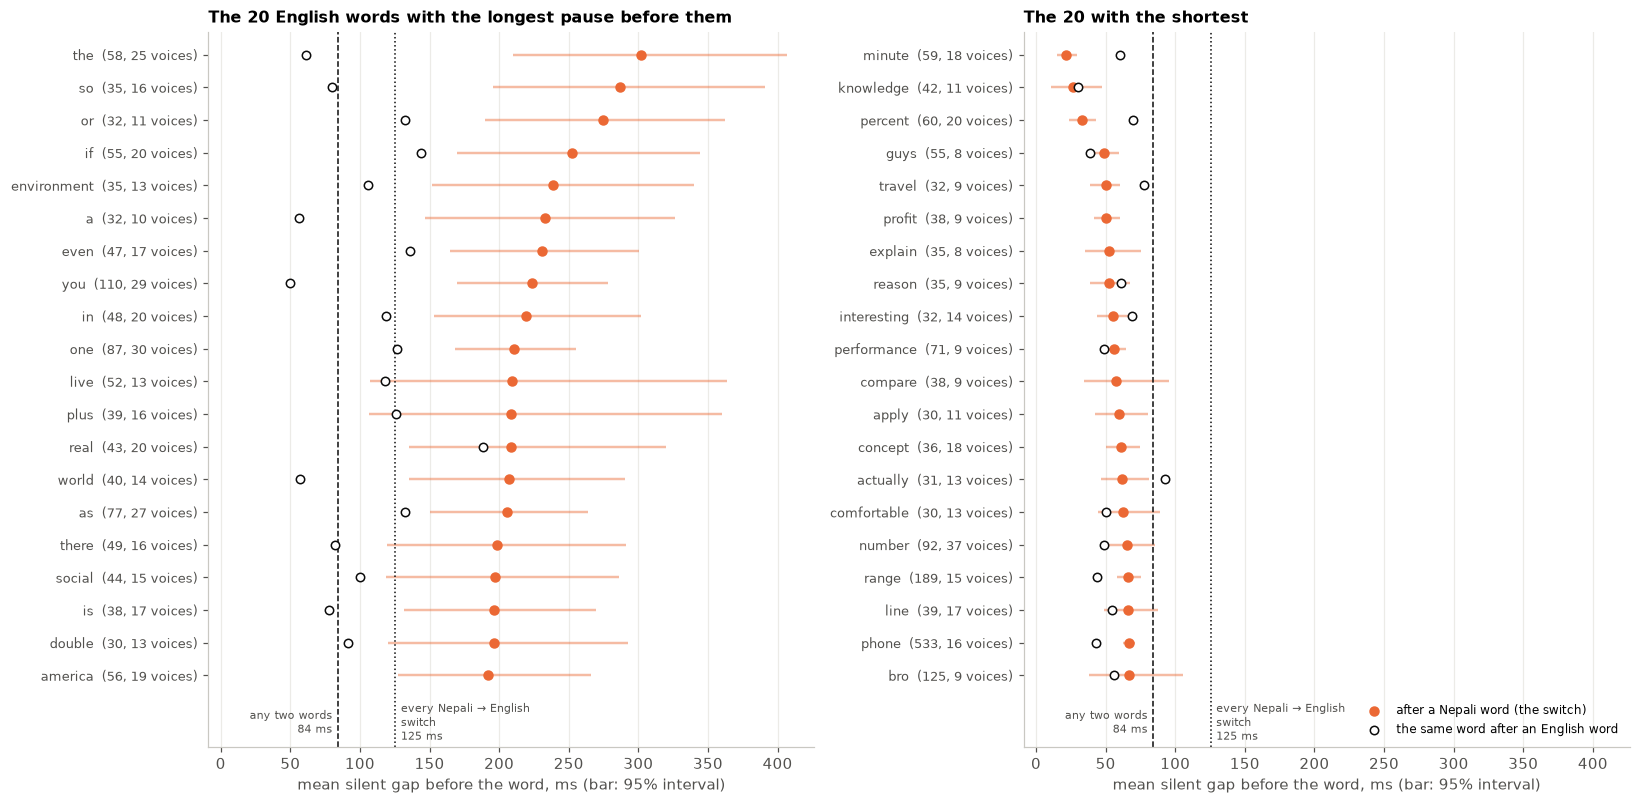

250 English words open 30+ switches from 8+ voices. Baseline: the silent gap between any two neighbouring words averages 84 ms (median 41), and before an English word that follows a Nepali one 125 ms.
per word it runs from 22 ms (minute) to 302 ms (the); a single word's mean is known to about ±38 ms. Of the 20 longest, 15 have their whole interval above the average switch, and of the 20 shortest 20 below it; the order inside each list is not known. On elevenlabs-scribe-v2's own words and timings the 207 words it also has rank alike (Spearman 0.87).


switches  voices  mean gap ms  gaps of 200+ ms %  after English ms
         word                                                                           
longest  the                58      25       302.00              45.00             61.00
         so                 35      16       287.00              43.00             80.00
         or                 32      11       275.00              50.00            133.00
         if                 55      20       253.00              33.00            144.00
         environment        35      13       239.00              34.00            106.00
         a                  32      10       233.00              28.00             57.00
         even               47      17       231.00              32.00            136.00
         you               110      29       224.00              30.00             50.00
         in                 48      20       219.00              31.00            119.00
         one                87      30       210.00              31.00            126.00
         live               52      13       210.00              19.00            118.00
         plus               39      16       209.00              21.00            126.00
         real               43      20       209.00              30.00            188.00
         world              40      14       207.00              30.00             57.00
         as                 77      27       206.00              31.00            133.00
         there              49      16       198.00              27.00             82.00
         social             44      15       197.00              25.00            100.00
         is                 38      17       197.00              26.00             78.00
         double             30      13       196.00              27.00             92.00
         america            56      19       192.00              27.00               NaN
shortest minute             59      18        22.00               0.00             60.00
         knowledge          42      11        26.00               2.00             30.00
         percent            60      20        33.00               0.00             70.00
         guys               55       8        48.00               2.00             39.00
         travel             32       9        50.00               0.00             78.00
         profit             38       9        51.00               0.00               NaN
         explain            35       8        53.00               3.00               NaN
         reason             35       9        53.00               3.00             61.00
         interesting        32      14        55.00               0.00             69.00
         performance        71       9        56.00               1.00             49.00
         compare            38       9        57.00               5.00               NaN
         apply              30      11        59.00               3.00               NaN
         concept            36      18        61.00               3.00               NaN
         actually           31      13        62.00               3.00             92.00
         comfortable        30      13        63.00               7.00             50.00
         number             92      37        65.00               5.00             49.00
         range             189      15        66.00               3.00             44.00
         line               39      17        66.00               3.00             55.00
         phone             533      16        67.00               2.00             43.00
         bro               125       9        67.00               4.00             56.00

In [12]:
def gap_by_word(b, min_n=30, min_voices=8, seed=0):
    """Each English word's mean gap when a Nepali word comes just before it, for the words seen
    ``min_n`` times from ``min_voices`` voices, with an interval that resamples its occurrences."""
    rng, rows = np.random.default_rng(seed), []
    for word, g in b[b.boundary == "Nepali → English"].groupby("word"):
        if len(g) < min_n or g.voice.nunique() < min_voices:
            continue
        ms = 1000 * g.gap.to_numpy()
        lo, hi = np.percentile(ms[rng.integers(0, len(ms), size=(1000, len(ms)))].mean(axis=1), [2.5, 97.5])
        rows.append({"word": word, "switches": len(ms), "voices": g.voice.nunique(), "mean gap ms": ms.mean(), "lo": lo, "hi": hi,
                     "gaps of 200+ ms %": 100 * g.long.mean()})
    out = pd.DataFrame(rows).set_index("word").sort_values("mean gap ms")
    after_en = b[b.boundary == "English → English"].groupby("word").gap.agg(["size", "mean"])
    after_en = after_en[after_en["size"] >= 10]
    return out.assign(**{"after English ms": 1000 * after_en["mean"].reindex(out.index)})


HESITATE = gap_by_word(B)
ANY_GAP = 1000 * B.gap.mean()
SWITCH_GAP = 1000 * B.gap[B.boundary == "Nepali → English"].mean()
N_SHOW = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 7.4), sharex=True)
for ax, t, title in ((axes[0], HESITATE.tail(N_SHOW).iloc[::-1], f"The {N_SHOW} English words with the longest pause before them"),
                     (axes[1], HESITATE.head(N_SHOW), f"The {N_SHOW} with the shortest")):
    y = np.arange(len(t))
    ax.hlines(y, t.lo, t.hi, color=SLOTS[1], lw=1.6, alpha=0.45)
    ax.scatter(t["mean gap ms"], y, s=34, color=SLOTS[1], zorder=3, label="after a Nepali word (the switch)")
    ax.scatter(t["after English ms"], y, s=30, facecolor="white", edgecolor=INK, lw=1, zorder=3, label="the same word after an English word")
    for x_, name, ls, side in ((ANY_GAP, "any two words", "--", "right"), (SWITCH_GAP, "every Nepali → English\nswitch", ":", "left")):
        ax.axvline(x_, color=INK, lw=1, ls=ls)
        ax.text(x_ + (4 if side == "left" else -4), len(t) + 0.45, f"{name}\n{x_:.0f} ms", fontsize=7.5, color=MUTED, ha=side, va="center")
    ax.set_yticks(y, [f"{w}  ({r.switches}, {r.voices} voices)" for w, r in zip(t.index, t.itertuples())], fontsize=8.5)
    ax.set_ylim(len(t) + 1.2, -0.7)
    ax.set(title=title, xlabel="mean silent gap before the word, ms (bar: 95% interval)")
    ax.grid(axis="y", visible=False)
axes[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()
save(fig, "03d_hesitation_words")
plt.show()

scribe_rank = gap_by_word(B_scribe)["mean gap ms"]
both = HESITATE["mean gap ms"].to_frame("label").join(scribe_rank.rename("scribe"), how="inner")
print(f"{len(HESITATE)} English words open 30+ switches from 8+ voices. Baseline: the silent gap between any two neighbouring words averages "
      f"{ANY_GAP:.0f} ms (median {1000 * B.gap.median():.0f}), and before an English word that follows a Nepali one {SWITCH_GAP:.0f} ms.")
print(f"per word it runs from {HESITATE['mean gap ms'].min():.0f} ms ({HESITATE.index[0]}) to {HESITATE['mean gap ms'].max():.0f} ms ({HESITATE.index[-1]}); "
      f"a single word's mean is known to about ±{((HESITATE.hi - HESITATE.lo) / 2).median():.0f} ms. Of the {N_SHOW} longest, {(HESITATE.tail(N_SHOW).lo > SWITCH_GAP).sum()} have their whole "
      f"interval above the average switch, and of the {N_SHOW} shortest {(HESITATE.head(N_SHOW).hi < SWITCH_GAP).sum()} below it; the order inside each list is not known. "
      f"On {SCRIBE}'s own words and timings the {len(both)} words it also has rank alike (Spearman {stats.spearmanr(both.label, both.scribe).statistic:.2f}).")
display(pd.concat({"longest": HESITATE.tail(N_SHOW).iloc[::-1], "shortest": HESITATE.head(N_SHOW)}).drop(columns=["lo", "hi"]).round(0))

**Does the speech speed up or slow down around a switch?** A rate in words or syllables per second
cannot be compared across the two languages, so the comparison is again the same word in two
places: how long a Nepali word lasts when the next word is English and when it is Nepali, and so
on. Only words with a plain space on both sides are used, which keeps the lengthening at the end
of a phrase out of it. A word's end is the less certain of its two edges, so a duration is
noisier than a gap; the interval on each line below says how small a change this data could
have shown. The picture after the table puts each line on
one axis, against the 20 ms frame that bounds how well a single word's length is known.

,words,difference ms,lo,hi,words where it is longer %,p,% of a typical word
"Nepali word: just before English, minus inside Nepali",196,1.60,-1.10,3.90,50.00,0.76,0.70
"Nepali word: just after English, minus inside Nepali",170,-1.40,-3.30,0.70,46.50,0.03,-0.60
"English word: alone between Nepali words, minus inside an English run",138,-5.50,-19.90,6.90,47.80,0.37,-3.40
"English word: first of a run, minus inside the run",164,5.50,0.30,10.50,62.20,0.0038,3.50
"English word: last of a run, minus inside the run",155,-10.20,-20.60,-2.00,40.00,0.0073,-6.40


a typical word inside a run lasts 221 ms in Nepali and 160 ms in English; the widest interval above is 13 ms either way and the narrowest 2 ms


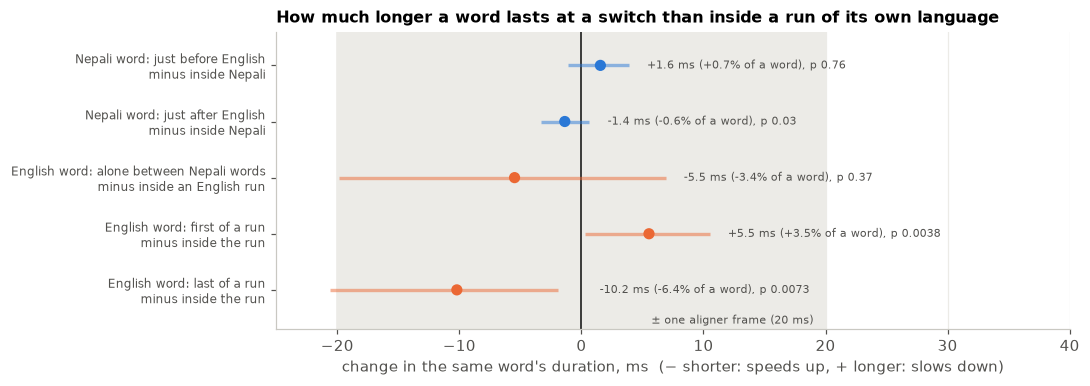

In [13]:
mid = W[(W.sep_before == "space") & (W.sep_after == "space") & (W.dur > 0) & W.kind.isin(["ne", "en"])
        & W.prev_kind.isin(["ne", "en"]) & W.next_kind.isin(["ne", "en"])]
mid = mid.assign(place=mid.prev_kind + " " + mid.kind + " " + mid.next_kind)
ne_mid, en_mid = mid[mid.kind == "ne"], mid[mid.kind == "en"]
SPEED = pd.DataFrame({
    "Nepali word: just before English, minus inside Nepali": same_word(ne_mid, "ne ne en", "ne ne ne", "dur", "place"),
    "Nepali word: just after English, minus inside Nepali": same_word(ne_mid, "en ne ne", "ne ne ne", "dur", "place"),
    "English word: alone between Nepali words, minus inside an English run": same_word(en_mid, "ne en ne", "en en en", "dur", "place", k=10),
    "English word: first of a run, minus inside the run": same_word(en_mid, "ne en en", "en en en", "dur", "place", k=10),
    "English word: last of a run, minus inside the run": same_word(en_mid, "en en ne", "en en en", "dur", "place", k=10),
}).T
typical = {"Nepali": 1000 * ne_mid.dur[ne_mid.place == "ne ne ne"].median(), "English": 1000 * en_mid.dur[en_mid.place == "en en en"].median()}
SPEED["% of a typical word"] = [100 * r["difference ms"] / typical[name.split()[0]] for name, r in SPEED.iterrows()]
display(SPEED.assign(p=SPEED.p.map(lambda p: small(p).lstrip("= "))).astype({"words": int}).round(1))
print(f"a typical word inside a run lasts {typical['Nepali']:.0f} ms in Nepali and {typical['English']:.0f} ms in English; "
      f"the widest interval above is {(SPEED.hi - SPEED.lo).max() / 2:.0f} ms either way and the narrowest {(SPEED.hi - SPEED.lo).min() / 2:.0f} ms")

# The table as a picture: each line is one comparison, its dot the change in a word's length and
# its bar the 95% interval; the band is one frame of the aligner either way, what a single
# word's length could be off by.
fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(SPEED))
colors = [SLOTS[0] if name.startswith("Nepali") else SLOTS[1] for name in SPEED.index]
ax.axvspan(-20, 20, color="#ecebe7", zorder=0)
ax.text(19, len(SPEED) - 0.35, "± one aligner frame (20 ms)", ha="right", va="bottom", fontsize=7.5, color=MUTED)
ax.axvline(0, color=INK, lw=1)
ax.hlines(y, SPEED.lo, SPEED.hi, color=colors, lw=2.2, alpha=0.5)
ax.scatter(SPEED["difference ms"], y, s=40, color=colors, zorder=3)
for i, r in enumerate(SPEED.itertuples()):
    ax.text(max(r.hi, 0) + 1.5, i, f"{r[2]:+.1f} ms ({r[-1]:+.1f}% of a word), p {small(r.p).lstrip('= ')}", va="center", fontsize=7.5, color=MUTED)
ax.set_yticks(y, [name.replace(", minus", "\nminus") for name in SPEED.index], fontsize=8)
ax.set_ylim(len(SPEED) - 0.3, -0.6)
ax.set_xlim(-25, 40)
ax.set(title="How much longer a word lasts at a switch than inside a run of its own language",
       xlabel="change in the same word's duration, ms  (− shorter: speeds up, + longer: slows down)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "03e_switch_speed")
plt.show()

## 7. Address and honorifics

Nepali grades its second person: *hajur* and *tapāī̃* are the high forms, *timī* the middle,
*tã* the low one, and the verb agrees with the choice. Which form a host uses to a guest, and
whether guests answer in kind, is a register question the transcript answers directly. *hajur*
on its own also serves as a polite backchannel ("yes?"), which is counted separately. English
*you* is the neutral escape from the choice, and its rate is a fourth column.

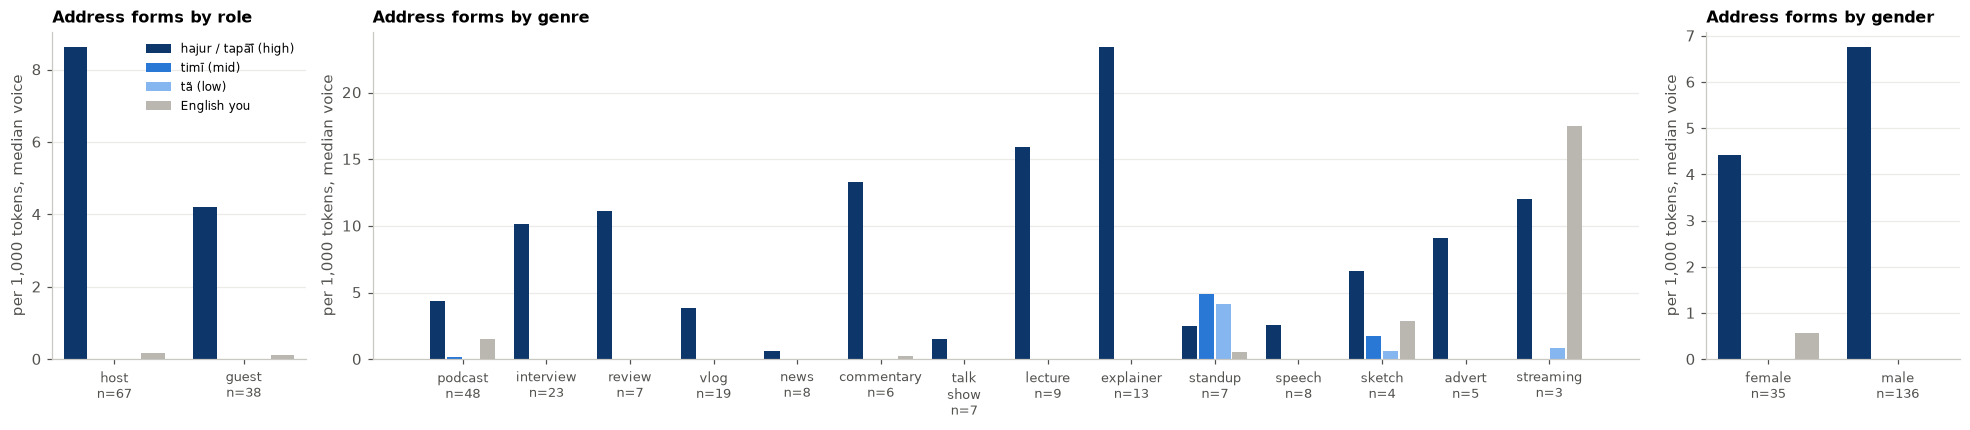

,high / 1000,of which bare hajur,mid / 1000,low / 1000,you / 1000
genre,,,,,
podcast,7.73,2.37,1.73,0.26,5.55
interview,20.61,8.29,1.00,0.54,0.18
review,12.33,0.63,0.02,0.00,1.66
vlog,17.02,1.00,0.28,0.65,1.55
news,1.28,0.07,0.13,0.03,0.24
commentary,14.33,0.07,0.00,0.00,0.39
talk_show,12.83,0.52,2.23,0.31,6.18
lecture,17.45,0.49,0.00,0.00,0.85
explainer,18.84,0.36,0.30,0.00,2.43


the low form tã appears in 38 of 171 voices (podcast 13, interview 10, standup 6, streaming 3, vlog 2, sketch 2, talk show 1, news 1); 60 voices use timī at all


In [14]:
HON_COLS = ["hon high / 1000", "hon mid / 1000", "hon low / 1000", "you / 1000"]
HON_COLORS = [RAMP[4], RAMP[2], RAMP[0], GREY]
HON_LABELS = ["hajur / tapāī̃ (high)", "timī (mid)", "tã (low)", "English you"]
by_groups = (("role", ROLES), ("genre", GENRE_GROUPS), ("gender", GENDERS))
fig, axes = plt.subplots(1, 3, figsize=(18, 4), gridspec_kw={"width_ratios": [len(order) + 1 for _, order in by_groups]})
for ax, (by, order) in zip(axes, by_groups):
    g = VV[VV[by].isin(order)].groupby(by)[HON_COLS].median().reindex(order)
    n = VV[VV[by].isin(order)].groupby(by).size().reindex(order, fill_value=0).astype(int)
    x = np.arange(len(order))
    for i, (col, color, label) in enumerate(zip(HON_COLS, HON_COLORS, HON_LABELS)):
        ax.bar(x + (i - 1.5) * 0.2, g[col], 0.18, color=color, label=label)
    ax.set_xticks(x, [f"{pretty(o).replace(' ', chr(10))}\nn={n[o]}" for o in order], fontsize=8.5)
    ax.set(title=f"Address forms by {by}", ylabel="per 1,000 tokens, median voice")
    ax.grid(axis="x", visible=False)
axes[0].legend(fontsize=8)
fig.tight_layout()
save(fig, "04_address_forms")
plt.show()

hon = usable.groupby("genre")[["hon_high", "hon_mid", "hon_low", "hajur_bare", "en_you", "tokens"]].sum().reindex(GENRES)
hon_t = pd.DataFrame({
    "high / 1000": 1000 * hon.hon_high / hon.tokens, "  of which bare hajur": 1000 * hon.hajur_bare / hon.tokens,
    "mid / 1000": 1000 * hon.hon_mid / hon.tokens, "low / 1000": 1000 * hon.hon_low / hon.tokens, "you / 1000": 1000 * hon.en_you / hon.tokens,
})
display(hon_t)
lo = VV[VV["hon low / 1000"] > 0]
print(f"the low form tã appears in {len(lo)} of {len(VV)} voices ({', '.join(f'{pretty(g)} {n}' for g, n in lo.genre.value_counts().items())}); "
      f"{(VV['hon mid / 1000'] > 0).sum()} voices use timī at all")

## 8. Discourse markers

Two closed lists. Nepali: *chāhī̃* (topic marker), *ni*, *hai*, *ani*, *haina* (tag), *bhaneko*
("that is"), *matlab*, *khai*, *la*. English: *so, like, actually, basically, okay, right, yeah,
literally, obviously, anyway, you know, I mean*. The English share of a voice's markers is a
sharper index of bilingual discourse than the English share of its words: *so* is the single
most frequent English token in the corpus, ahead of *the*, and a speaker who structures Nepali
talk with *so* and *like* is doing something different from one who names a *phone*.

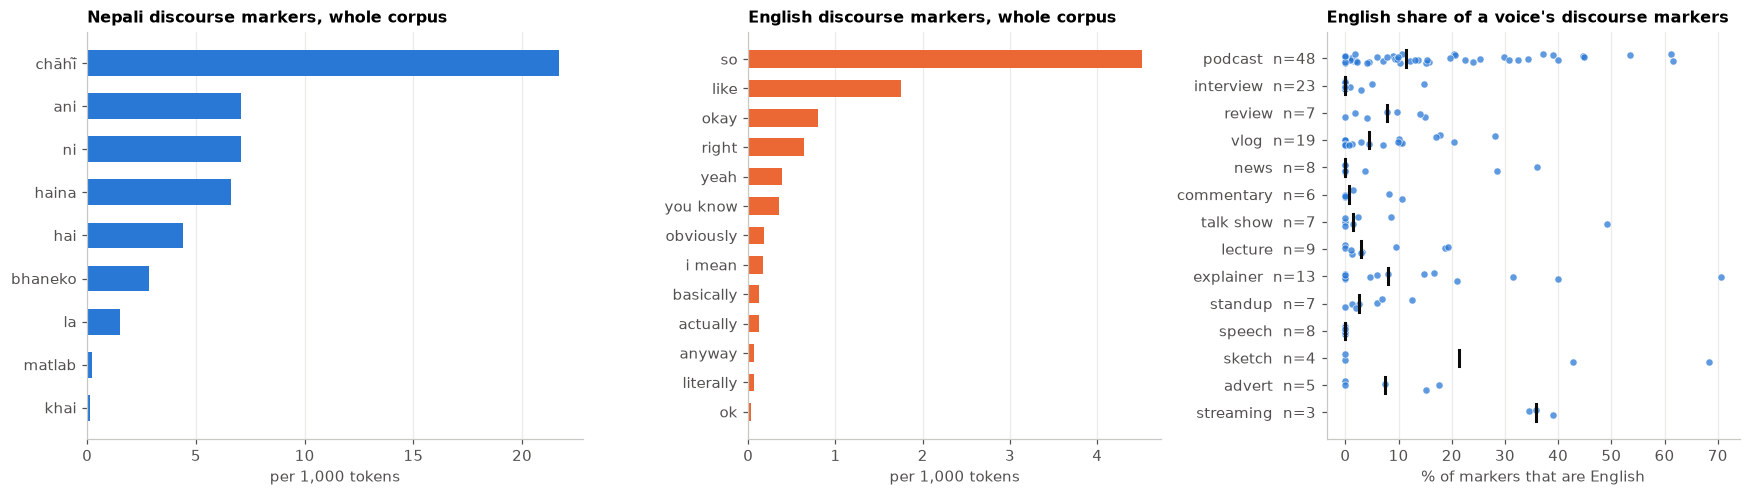

voices  dm ne / 1000  dm en / 1000  en dm share %
gender female       35.00         49.06          4.09           6.90
       male        136.00         45.83          1.27           2.75
age    20_39       103.00         57.45          3.37           6.02
       40_59        48.00         33.39          0.13           0.30
       60_79        15.00         40.93          0.34           0.79
       80_plus       4.00         39.86          0.00           0.00
role   host         67.00         43.15          0.97           2.98
       guest        38.00         41.40          1.52           2.49
genre  podcast      48.00         59.38          7.87          11.42
       interview    23.00         44.92          0.00           0.00
       review        7.00         64.21          2.93           7.74
       vlog         19.00         71.95          5.83           4.44
       news          8.00          1.18          0.00           0.00
       commentary    6.00         51.61          0.49           0.75
       talk_show     7.00         63.25          1.34           1.39
       lecture       9.00         49.36          1.27           2.86
       explainer    13.00         38.79          3.37           8.00
       standup       7.00         52.57          1.43           2.65
       speech        8.00          6.70          0.00           0.00
       sketch        4.00         16.27          4.97          21.43
       advert        5.00         56.68          4.93           7.41
       streaming     3.00         43.15         24.10          35.77

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax = axes[0]
dm_ne = usable[[c for c in usable.columns if c.startswith("dmne_")]].sum().sort_values()
dm_ne.index = [c.replace("dmne_", "") for c in dm_ne.index]
ax.barh(dm_ne.index, 1000 * dm_ne / usable.tokens.sum(), color=RAMP[2], height=0.6)
ax.set(title="Nepali discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

en_dm = Counter()
for text in usable.text:
    low = [w.strip(EDGE).lower() for w in text.split()]
    en_dm.update(w for w in low if w in DM_EN)
    en_dm.update(" ".join(b) for b in zip(low, low[1:]) if b in DM_EN_BIGRAM)
ax = axes[1]
s = pd.Series(en_dm).sort_values()
ax.barh(s.index, 1000 * s / usable.tokens.sum(), color=SLOTS[1], height=0.6)
ax.set(title="English discourse markers, whole corpus", xlabel="per 1,000 tokens")
ax.grid(axis="y", visible=False)

ax = axes[2]
strip(ax, VV, "en dm share %", "genre", GENRE_GROUPS, GENRE_COLOR, title="English share of a voice's discourse markers", xlabel="% of markers that are English", compact=True)
fig.tight_layout()
save(fig, "05_discourse_markers")
plt.show()
dm_tab = {}
for by, order in (("gender", GENDERS), ("age", AGES), ("role", ROLES), ("genre", GENRE_GROUPS)):
    for g in order:
        sub = VV[VV[by] == g]
        if len(sub) >= 3:
            dm_tab[(by, g)] = {"voices": len(sub), "dm ne / 1000": sub["dm ne / 1000"].median(), "dm en / 1000": sub["dm en / 1000"].median(),
                               "en dm share %": sub["en dm share %"].median()}
display(pd.DataFrame(dm_tab).T.round(2))

## 9. Accommodation between host and guest

Speech accommodation predicts that a host's mixing moves toward the guest's. The corpus can test
it two ways. Across episodes: each episode with a resolved host voice and at least one guest
voice gives one (host, guest) pair of English shares. Within a host: the series hosts appear in
many episodes, so for each of them the correlation between their own English share and their
guest's, episode by episode, controls for the host entirely. Both need 100+ attributed tokens
per speaker per episode.

Two things other than accommodation would put host and guest on the same line. Shows differ: a
host of an interview series in plain Nepali and the host of a tech podcast are far apart before
any guest speaks, and so are their guests, which is why the within-host correlation is the one
that matters. And topics differ: an episode about technology puts English in both mouths. The
last lines below take the topic's usual English share out of both speakers and correlate what
is left.

34 episodes with one resolved host and 42 resolved guests


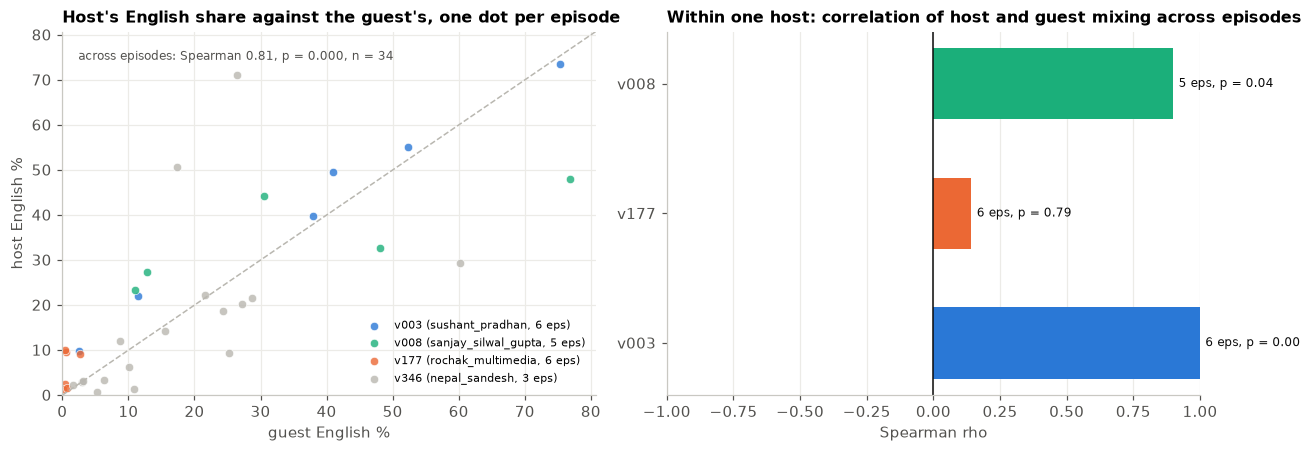

,host,show,episodes,host mean %,host sd %,guest sd %,Spearman,p
0,v003,sushant_pradhan,6,41.66,23.11,26.70,1.00,0.00
2,v177,rochak_multimedia,6,5.71,4.26,0.92,0.14,0.79
1,v008,sanjay_silwal_gupta,5,35.13,10.68,27.42,0.90,0.04


17 of the 34 episodes belong to three hosts (v003 6, v177 6, v008 5); 15 hosts in all
the topic's English share goes with the host's at Spearman 0.31 and the guest's at 0.36; with it taken out of both, host and guest still correlate at 0.79 (p < 0.0001)


In [16]:
ep_voice = attributed.groupby(["episode", "speaker"]).agg(tokens=("tokens", "sum"), lat=("lat", "sum"), mixed=("mixed", "sum"))
ep_voice = ep_voice[ep_voice.tokens >= 100]
ep_voice["english %"] = 100 * (ep_voice.lat + ep_voice.mixed) / ep_voice.tokens
ep_voice["role"] = [ROLE.get((e, v)) for e, v in ep_voice.index]
pairs = []
for e, sub in ep_voice.groupby(level=0):
    hosts_, guests_ = sub[sub.role == "host"], sub[sub.role == "guest"]
    if len(hosts_) == 1 and len(guests_) >= 1:
        pairs.append({"episode": e, "host": hosts_.index[0][1], "host %": hosts_["english %"].iloc[0],
                      "guest %": np.average(guests_["english %"], weights=guests_.tokens), "guests": len(guests_), "show": EP_SHOW[e]})
pairs = pd.DataFrame(pairs)
print(f"{len(pairs)} episodes with one resolved host and {pairs.guests.sum()} resolved guests")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
host_ids = pairs.host.value_counts()
host_color = {h: SLOTS[i] if i < 3 else GREY for i, h in enumerate(host_ids.index)}
for h, sub in pairs.groupby("host"):
    ax.scatter(sub["guest %"], sub["host %"], s=30, color=host_color[h], alpha=0.8, edgecolor="white", linewidth=0.5,
               label=f"{h} ({sub.show.iloc[0]}, {len(sub)} eps)" if len(sub) >= 3 else None)
lim = [0, max(pairs["guest %"].max(), pairs["host %"].max()) * 1.05]
ax.plot(lim, lim, color=GREY, lw=1, ls="--")
ax.set(title="Host's English share against the guest's, one dot per episode", xlabel="guest English %", ylabel="host English %", xlim=lim, ylim=lim)
ax.legend(fontsize=7.5, loc="lower right")
rho_all = stats.spearmanr(pairs["guest %"], pairs["host %"])
ax.text(0.03, 0.95, f"across episodes: Spearman {rho_all[0]:.2f}, p = {rho_all[1]:.3f}, n = {len(pairs)}", transform=ax.transAxes, va="top", fontsize=8, color=MUTED)

ax = axes[1]
within = []
for h, sub in pairs.groupby("host"):
    if len(sub) >= 5:
        r = stats.spearmanr(sub["guest %"], sub["host %"])
        within.append({"host": h, "show": sub.show.iloc[0], "episodes": len(sub), "host mean %": sub["host %"].mean(), "host sd %": sub["host %"].std(),
                       "guest sd %": sub["guest %"].std(), "Spearman": r[0], "p": r[1]})
within = pd.DataFrame(within).sort_values("episodes", ascending=False)
if len(within):
    ax.barh(within.host, within.Spearman, color=[host_color[h] for h in within.host], height=0.55)
    for y, r in enumerate(within.itertuples()):
        ax.text(r.Spearman + (0.02 if r.Spearman >= 0 else -0.02), y, f"{r.episodes} eps, p = {r.p:.2f}", va="center", ha="left" if r.Spearman >= 0 else "right", fontsize=8, color=INK)
    ax.axvline(0, color=INK, lw=1)
    ax.set(title="Within one host: correlation of host and guest mixing across episodes", xlabel="Spearman rho", xlim=(-1, 1))
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "06_accommodation")
plt.show()
display(within.round(2))

by_topic = usable.groupby("topic")[["lat", "mixed", "tokens"]].sum()
pairs["topic"] = [EP_META[e].get("topic") or "unclassified" for e in pairs.episode]
pairs["topic %"] = pairs.topic.map(100 * (by_topic.lat + by_topic.mixed) / by_topic.tokens)


def without(y, x):
    """The part of ``y``'s rank that ``x``'s rank does not predict."""
    y, X = y.rank().to_numpy(), np.column_stack([np.ones(len(x)), x.rank().to_numpy()])
    return y - X @ np.linalg.lstsq(X, y, rcond=None)[0]


rho_topic = stats.pearsonr(without(pairs["host %"], pairs["topic %"]), without(pairs["guest %"], pairs["topic %"]))
top3 = pairs.host.value_counts().head(3)
print(f"{top3.sum()} of the {len(pairs)} episodes belong to three hosts ({', '.join(f'{h} {n}' for h, n in top3.items())}); {pairs.host.nunique()} hosts in all")
print(f"the topic's English share goes with the host's at Spearman {stats.spearmanr(pairs['topic %'], pairs['host %'])[0]:.2f} and the guest's at "
      f"{stats.spearmanr(pairs['topic %'], pairs['guest %'])[0]:.2f}; with it taken out of both, host and guest still correlate at {rho_topic[0]:.2f} (p {small(rho_topic[1])})")

## 10. Turn-taking by gender pairing

Crosstalk and hand-overs are measured on every clip (D77, D78) but carry no speaker, so the
question the corpus can answer is about the *composition* of a conversation, not who interrupts
whom: is a mixed-gender episode more or less overlapped than a same-gender one? Only episodes
whose every voice has a resolved gender count. Composition is a property of the episode, so n is
episodes, and an episode with a single voice falls out.

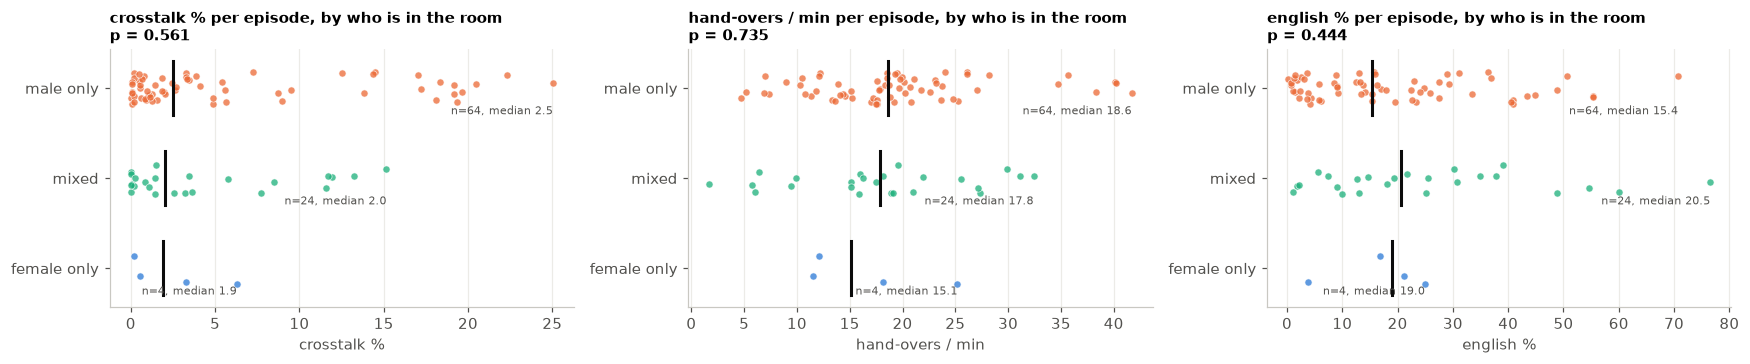

composition,one voice,male only,mixed,female only
episodes,250,64,24,4


In [17]:
ep_rows = []
for e, sub in usable.groupby("episode"):
    voices = [v for v in set(sub.voice.dropna()) if voice_talk[v] > 0]
    genders = {SPK.gender[v] for v in voices}
    if not voices or "unresolved" in genders or len(voices) < 2:
        comp = "unresolved" if "unresolved" in genders or not voices else "one voice"
    else:
        comp = "mixed" if len(genders) == 2 else f"{genders.pop()} only"
    ep_rows.append({"episode": e, "genre": sub.genre.iloc[0], "show": EP_SHOW[e], "voices": len(voices), "composition": comp,
                    "minutes": sub.duration.sum() / 60, "crosstalk %": 100 * sub.overlap_s.sum() / sub.duration.sum(),
                    "hand-overs / min": 60 * sub.turn_changes.sum() / sub.duration.sum(),
                    "english %": 100 * (sub.lat.sum() + sub.mixed.sum()) / sub.tokens.sum()})
EP = pd.DataFrame(ep_rows).set_index("episode")
COMPS = ["male only", "mixed", "female only"]
COMP_COLOR = {"male only": GENDER_COLOR["male"], "mixed": GENDER_COLOR["mixed"], "female only": GENDER_COLOR["female"]}
conv = EP[EP.composition.isin(COMPS)]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, col in zip(axes, ("crosstalk %", "hand-overs / min", "english %")):
    strip(ax, conv, col, "composition", COMPS, COMP_COLOR, title=f"{col} per episode, by who is in the room", xlabel=col)
    ax.set_title(f"{col} per episode, by who is in the room\np = {test(conv, col, 'composition', COMPS):.3f}", fontsize=9.5)
fig.tight_layout()
save(fig, "07_pairing")
plt.show()
display(EP.composition.value_counts().rename("episodes").to_frame().T)

## 11. What a comparison could detect

The paper's comparisons are between groups of voices. With the voices there are, and the
spread between voices that the corpus shows, the minimum difference in English share (percentage
points) a two-sample test would detect at 80% power and α = 0.05 is given for each split, next
to the difference actually observed. The last column is how many voices *per group* would be
needed to detect the target in the column before it: five points of English share, or one
switch per hundred tokens. This is a t-test power calculation on a quantity that is not normal, so
it is a guide to scale, not a promise.

In [18]:
def mde(n1, n2, sd, alpha=0.05, power=0.8):
    df = n1 + n2 - 2
    return (stats.t.ppf(1 - alpha / 2, df) + stats.t.ppf(power, df)) * sd * np.sqrt(1 / n1 + 1 / n2)


def n_for(delta, sd, alpha=0.05, power=0.8):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return int(np.ceil(2 * (z * sd / delta) ** 2))


g1, g2 = VV.genre.value_counts().index[:2]  # the two genres with the most voices
power_rows = []
for metric, target in (("english %", 5.0), ("switches / 100", 1.0)):
    for by, a, b, frame, label in (("gender", "female", "male", VV, "female vs male"), ("gender", "female", "male", pod, "female vs male, podcasts only"),
                                   ("age", "20_39", "40_59", VV, "20-39 vs 40-59"), ("age", "40_59", "60_79", VV, "40-59 vs 60-79"),
                                   ("role", "host", "guest", VV, "host vs guest"), ("genre", g1, g2, VV, f"{pretty(g1)} vs {pretty(g2)}")):
        x, y = frame.loc[frame[by] == a, metric], frame.loc[frame[by] == b, metric]
        if len(x) < 2 or len(y) < 2:
            continue
        sd = np.sqrt(((len(x) - 1) * x.var() + (len(y) - 1) * y.var()) / (len(x) + len(y) - 2))
        power_rows.append({"metric": metric, "comparison": label, "n": f"{len(x)} vs {len(y)}", "pooled sd": sd, "observed diff": x.mean() - y.mean(),
                           "detectable diff": mde(len(x), len(y), sd), "target": target, "n/group for target": n_for(target, sd)})
POWER = pd.DataFrame(power_rows).set_index(["metric", "comparison"])
display(POWER.round(2))

n  pooled sd  observed diff  detectable diff  target  n/group for target
metric         comparison                                                                                                     
english %      female vs male                 35 vs 136      16.19          -1.90             8.64    5.00                 165
               female vs male, podcasts only   14 vs 34      18.14          -3.99            16.49    5.00                 207
               20-39 vs 40-59                 103 vs 48      15.81           4.62             7.79    5.00                 157
               40-59 vs 60-79                  48 vs 15      20.10           2.18            16.92    5.00                 254
               host vs guest                   67 vs 38      17.34           0.25             9.96    5.00                 189
               podcast vs interview            48 vs 23      15.64          22.08            11.27    5.00                 154
switches / 100 female vs male                 35 vs 136      11.28          -0.10             6.03    1.00                1999
               female vs male, podcasts only   14 vs 34       9.85           0.70             8.95    1.00                1523
               20-39 vs 40-59                 103 vs 48      10.21           9.37             5.03    1.00                1636
               40-59 vs 60-79                  48 vs 15       9.81           3.00             8.26    1.00                1511
               host vs guest                   67 vs 38      11.22           4.10             6.44    1.00                1976
               podcast vs interview            48 vs 23       9.06          13.41             6.53    1.00                1290

## 12. Verdict

Printed from the frames above, so a rerun on a newer export rewrites it.

In [19]:
def known(field):
    k = VV[field] != "unresolved"
    return f"{k.sum()} of {len(VV)} voices ({VV.talk_min[k].sum() / VV.talk_min.sum():.0%} of their speech)"


g_n = VV.gender.value_counts()
a_n = VV.age.value_counts()
r_n = VV.role.value_counts()
lead = attributed.groupby(["genre", "speaker"]).tokens.sum()
lead = lead.groupby(level=0).max() / lead.groupby(level=0).sum()  # the largest voice's share of a genre's attributed tokens
age_e, fem_e = model_row("english %", "age, per bracket"), model_row("english %", "female vs male")
age_s = model_row("switches / 100", "age, per bracket")
pause, pause_s = PAUSES.loc["label words, forced aligner"], PAUSES.loc[f"{SCRIBE}, its own"]
p_gender = POWER.loc[("english %", "female vs male")]
p_gender_pod = POWER.loc[("english %", "female vs male, podcasts only")] if ("english %", "female vs male, podcasts only") in POWER.index else None
lines = [
    f"UNITS     {len(SPK)} voices in {usable.episode.nunique()} episodes; {len(VV)} voices carry {MIN_TOKENS}+ attributed tokens and are the usable n.",
    f"RECORDED  gender known for {known('gender')}; age {known('age')}; role {known('role')}.",
    f"          cells: " + ", ".join(f"{g}/{pretty(a)} {int(grid.loc[(g, a), 'voices'])}" for g in GENDERS for a in AGES) + " voices (any talk time).",
    f"          women hold {f_in.min():.0%} ({pretty(f_in.idxmin())}) to {f_in.max():.0%} ({pretty(f_in.idxmax())}) of the gender-known speech by genre: gender and genre are confounded.",
    f"GENRES    {len(GENRE_GROUPS)} of {len(GENRES)} genres hold 3+ usable voices: " + ", ".join(f"{pretty(g)} {(VV.genre == g).sum()}" for g in GENRE_GROUPS) + ".",
    f"          one voice holds over half of the attributed tokens in: " + (", ".join(f"{pretty(g)} ({lead[g]:.0%})" for g in GENRES if lead.get(g, 0) > 0.5) or "no genre") + ".",
    f"REFUSED   dialect/region and name (D56). ABSENT: education, occupation, L1, ethnicity, diaspora status, upload date.",
    f"DERIVED   English share, switch rate, run lengths, integrated stems, function-word share, address forms, discourse markers, accommodation, pairing, pauses and word durations: all from the reference and its timed words.",
    f"MIXING    median voice {VV['english %'].median():.0f}% English, {VV['switches / 100'].median():.1f} switches / 100 tokens; "
    f"{100 * usable.run_tok_1.sum() / tot_runs:.0f}% of in-sentence English is a single word (insertion), {100 * usable.run_tok_6.sum() / tot_runs:.0f}% runs of 6+ (alternation).",
    f"PEOPLE    with genre and show held fixed ({int(age_e.voices)} voices on {int(age_e.shows)} shows): English share moves {age_e.coef:+.1f} points per age bracket "
    f"[{age_e.lo:+.1f}, {age_e.hi:+.1f}] and {fem_e.coef:+.1f} for women against men [{fem_e.lo:+.1f}, {fem_e.hi:+.1f}].",
    f"          of {len(MODELS)} coefficients {int((MODELS.p < 0.05).sum())} are under 0.05 alone and {int((MODELS.Holm < 0.05).sum())} survive the Holm correction"
    + (": " + "; ".join(f"{r.measure} by {r.term}" for r in MODELS[MODELS.Holm < 0.05].itertuples()) if (MODELS.Holm < 0.05).any() else "") + ".",
    f"          switch rate by age, at the same English share: {age_s.coef:+.2f} switches / 100 per bracket [{age_s.lo:+.2f}, {age_s.hi:+.2f}], p {small(age_s.p)}, Holm p {small(age_s.Holm)}; "
    f"inside the podcasts {checks['podcasts only']['switches / 100 per bracket']:+.2f} (p {small(checks['podcasts only']['p'])}, {int(checks['podcasts only']['voices'])} voices), "
    f"on verified clips {checks['verified clips only']['switches / 100 per bracket']:+.2f} (p {small(checks['verified clips only']['p'])}).",
    f"SWITCH    {len(switch_in):,} switches into English inside a sentence, {100 * single.mean():.0f}% one word long, over {len(types):,} different words; commonest: {', '.join(types.index[:8])}.",
    f"          a gap of 200+ ms comes before {pause.loc['Nepali → English', 'gaps of 200+ ms %']:.0f}% of switches into English against {pause.loc['Nepali → Nepali', 'gaps of 200+ ms %']:.0f}% of Nepali-to-Nepali boundaries "
    f"(median voice of {int(pause.voices.iloc[0])}; longer in {pause.loc['Nepali → English', 'voices with a longer gap %']:.0f}% of voices; "
    f"{pause_s.loc['Nepali → English', 'gaps of 200+ ms %']:.0f}% against {pause_s.loc['Nepali → Nepali', 'gaps of 200+ ms %']:.0f}% on the second recogniser's own timings).",
    f"          the same English word waits {FIXED['difference ms'].iloc[0]:+.0f} ms longer after a Nepali word than after an English one [{FIXED.lo.iloc[0]:+.0f}, {FIXED.hi.iloc[0]:+.0f}]; "
    f"the same Nepali word {FIXED['difference ms'].iloc[1]:+.0f} ms after English [{FIXED.lo.iloc[1]:+.0f}, {FIXED.hi.iloc[1]:+.0f}].",
    f"          word durations around a switch change by {SPEED['difference ms'].iloc[0]:+.1f} ms before it and {SPEED['difference ms'].iloc[1]:+.1f} ms after it, "
    f"both inside {max(abs(SPEED.lo.iloc[:2]).max(), abs(SPEED.hi.iloc[:2]).max()):.0f} ms of zero: no change of pace the data can see.",
    f"ADDRESS   high forms {hon_t['high / 1000'].mean():.1f} / 1000 tokens across genres; tã in {len(lo)} voices; timī in {(VV['hon mid / 1000'] > 0).sum()}.",
    f"MARKERS   median voice: {VV['en dm share %'].median():.0f}% of its discourse markers are English.",
    f"ACCOMMOD. {len(pairs)} host-guest episodes, across-episode Spearman {rho_all[0]:.2f} (p = {rho_all[1]:.2f}); "
    + "; ".join(f"{r.host} within-host rho {r.Spearman:.2f} over {r.episodes} eps" for r in within.itertuples())
    + f"; {rho_topic[0]:.2f} with the topic's English share taken out.",
    f"PAIRING   episodes by composition: " + ", ".join(f"{c} {int((EP.composition == c).sum())}" for c in COMPS) + f"; crosstalk p = {test(conv, 'crosstalk %', 'composition', COMPS):.2f}.",
    f"POWER     gender split detects a {p_gender['detectable diff']:.0f}-point English-share difference (observed {p_gender['observed diff']:+.0f}); "
    f"a 5-point difference needs {int(p_gender['n/group for target'])} voices per group at the observed spread.",
]
if p_gender_pod is not None:
    lines.append(f"          within podcasts: detects {p_gender_pod['detectable diff']:.0f} points with n {p_gender_pod['n']}.")
lines += [
    "SUPPORTS  a descriptive paper on the *form* of Nepali-English mixing (insertion vs alternation, integration, markers, address, the pause before a switch) and how it differs by genre;",
    "          an accommodation study within the recurring hosts; a register contrast between the genres that hold enough voices (GENRES).",
    "          a genre that one voice dominates illustrates a register but cannot stand for one.",
    "DOES NOT  support a Labovian social-stratification study: no region, class, education or L1; no difference by gender, age or role survives the correction;",
    "          gender and age are both confounded with genre,",
    f"          and of the {len(VV)} usable voices {int((VV.gender == 'female').sum())} are women and {int(((VV.gender == 'female') & VV.age.isin(['60_79', '80_plus'])).sum())} are women over 60;",
    "          any gender or age claim needs more female and older voices inside one genre, not more hours of the same speakers.",
    "CAVEAT    references are lightly checked fusions of three recognisers (EDA); demographics are the annotator's reading of a public episode, not self-report.",
]
print("\n".join(lines))

UNITS     358 voices in 342 episodes; 171 voices carry 300+ attributed tokens and are the usable n.
RECORDED  gender known for 171 of 171 voices (100% of their speech); age 171 of 171 voices (100% of their speech); role 105 of 171 voices (76% of their speech).
          cells: female/under 20 2, female/20-39 66, female/40-59 21, female/60-79 2, female/80 plus 0, male/under 20 1, male/20-39 166, male/40-59 77, male/60-79 17, male/80 plus 5 voices (any talk time).
          women hold 0% (lecture) to 74% (review) of the gender-known speech by genre: gender and genre are confounded.
GENRES    14 of 17 genres hold 3+ usable voices: podcast 48, interview 23, review 7, vlog 19, news 8, commentary 6, talk show 7, lecture 9, explainer 13, standup 7, speech 8, sketch 4, advert 5, streaming 3.
          one voice holds over half of the attributed tokens in: review (72%), commentary (54%), audiobook (62%), sketch (57%), streaming (54%).
REFUSED   dialect/region and name (D56). ABSENT: education, 